# Обзор бизнес-показателей маркетплейса и анализ результатов A/B тестирования

Автор: Ангелина Гольцева

Дата: 02.06.2026

### Введение

**Цель проекта** - по данным за 2024 год провести верхнеуровневую оценку здоровья продукта, найти инсайты и точки роста, после чего провести анализ результатов проведенного A/B тестирования.

**Задачи проекта**

В рамках данного проекта проведен комплексный анализ данных:
- получена верхнеуровневая оценка здоровья продукта по основным показателям маркетплейса;
- дана оценка юнит-экономики маркетплейса;
- произведена сегментация пользователей по различным признакам, проведен анализ метрик по сегментам;
- найдены точки роста продукта и сформулированы гипотезы для его развития;
- проанализированы результаты A/B-теста по одной из гипотез;
- сформулированы рекоменации заказчику на основе исследовательского анализа и результатов теста.

<b><a href="https://docs.google.com/presentation/d/1wBbSNdd3Le-MRBNWSmU2MHzvvr1YLbrbphLXlp32Knk/edit?usp=sharing" target="_blank">Ссылка на презентацию с основными тезисами исследовательского анализа</a></b>

## Исследовательский анализ

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [3]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


In [4]:
df_orders.duplicated(subset=None, keep='first').sum()

0

In [5]:
df_campaign_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


In [6]:
df_campaign_costs.duplicated(subset=None, keep='first').sum()

0

In [7]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


In [8]:
df_users.duplicated(subset=None, keep='first').sum()

0

In [9]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


In [10]:
df_events.duplicated(subset=None, keep='first').sum()

0

### Обзор ключевых метрик

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

#### Метрики аудитории

**Динамика набора аудитории**

In [11]:
df_users['registration_dt'] = df_users['registration_date'].dt.date
daily_users = df_users.groupby('registration_dt')['user_id'].nunique().reset_index().rename(columns={'user_id':'new_users'})
daily_users['rolling_mean_week'] = daily_users['new_users'].rolling(window=7).mean()
daily_users['rolling_mean_month'] = daily_users['new_users'].rolling(window=30).mean()

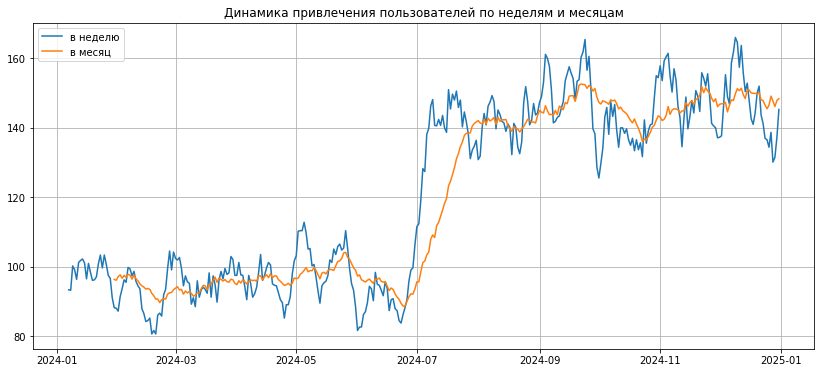

In [12]:
plt.figure(figsize=(14,6))

plt.plot(daily_users['registration_dt'], daily_users['rolling_mean_week'], label='в неделю')
plt.plot(daily_users['registration_dt'], daily_users['rolling_mean_month'], label='в месяц')

plt.title('Динамика привлечения пользователей по неделям и месяцам')
plt.legend()
plt.grid()
plt.show()

**Размер активной аудитории**

In [13]:
dau = df_events.groupby('event_date')['user_id'].nunique().reset_index().rename(columns={'user_id':'active_users'})
wau = df_events[df_events['event_week'] < df_events['event_week'].max()].groupby('event_week')['user_id'].nunique().reset_index().rename(columns={'user_id':'active_users'})
mau = df_events.groupby('event_month')['user_id'].nunique().reset_index().rename(columns={'user_id':'active_users'})

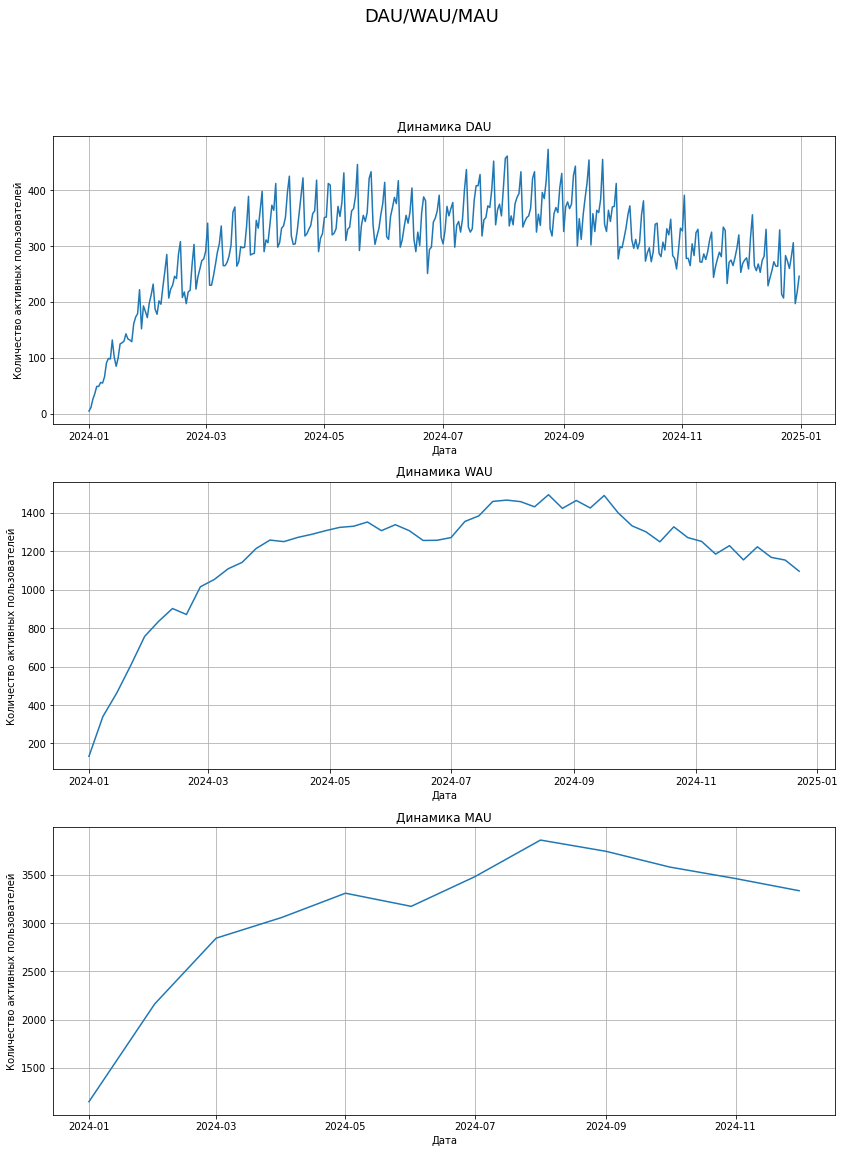

In [14]:
fig, axes = plt.subplots(3,1,figsize=(14,18))

axes[0].plot(dau['event_date'], dau['active_users'])
axes[0].set_title('Динамика DAU')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество активных пользователей')
axes[0].grid()

axes[1].plot(wau['event_week'], wau['active_users'])
axes[1].set_title('Динамика WAU')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество активных пользователей')
axes[1].grid()

axes[2].plot(mau['event_month'], mau['active_users'])
axes[2].set_title('Динамика MAU')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Количество активных пользователей')
axes[2].grid()

plt.suptitle(f'DAU/WAU/MAU', fontsize=18)
plt.show()

**Retention по неделям**

In [15]:
first_activity = df_events.groupby('user_id')['event_month'].min().reset_index()
first_activity.columns = ['user_id', 'cohort_month']

active_months = df_events[['user_id','event_month']].drop_duplicates()

retention = active_months.merge(first_activity, on='user_id')
retention['n_month'] = (retention['event_month'].dt.year - retention['cohort_month'].dt.year) * 12 + (retention['event_month'].dt.month - retention['cohort_month'].dt.month)

retention_rate = retention.groupby(['cohort_month','n_month'])['user_id'].nunique().unstack(fill_value=0)

cohort_size = first_activity.groupby('cohort_month')['user_id'].nunique()

retention_rate = retention_rate.div(cohort_size, axis=0)
retention_rate

n_month,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2024-01-01,1.0,0.547433,0.248042,0.110531,0.055701,0.026110,0.014795,0.006963,0.000870,0.001741,0.000870,0.00087
2024-02-01,1.0,0.502935,0.213307,0.108284,0.050228,0.018917,0.009785,0.003262,0.001305,0.000000,0.000652,0.00000
2024-03-01,1.0,0.467562,0.230425,0.112416,0.054251,0.026846,0.010067,0.003356,0.001119,0.001678,0.000000,0.00000
2024-04-01,1.0,0.481063,0.232335,0.114189,0.053137,0.027134,0.013002,0.005653,0.002261,0.000000,0.000000,0.00000
2024-05-01,1.0,0.473308,0.207485,0.096313,0.042378,0.020363,0.007155,0.003853,0.000000,0.000000,0.000000,0.00000
2024-06-01,1.0,0.457680,0.213793,0.086520,0.040752,0.021317,0.005016,0.000000,0.000000,0.000000,0.000000,0.00000
2024-07-01,1.0,0.449975,0.195170,0.093642,0.044850,0.016264,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2024-08-01,1.0,0.388619,0.172916,0.086458,0.039259,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2024-09-01,1.0,0.381193,0.191743,0.081651,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


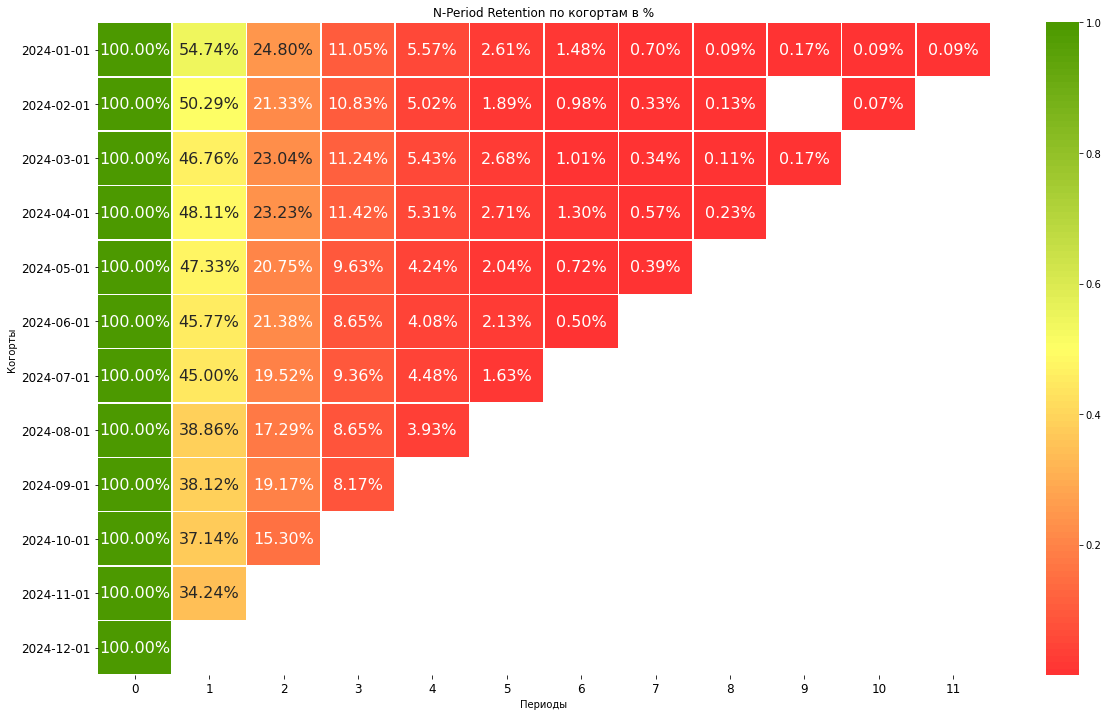

In [16]:
retention_rate[retention_rate == 0] = float('nan')

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100) # красивые цвета heatmap

retention_rate.index = pd.to_datetime(retention_rate.index).strftime('%Y-%m-%d')

plt.subplots(figsize=(20,12))
sns.heatmap(retention_rate,
           cmap=cmap,
           annot=True,
           fmt='.2%',
           linewidth=0.5,
           annot_kws={"size": 16})

plt.title('N-Period Retention по когортам в %')
plt.xlabel('Периоды')
plt.ylabel('Когорты')
plt.yticks(rotation=0)
plt.tick_params(labelsize=12)
plt.show()

На следующий месяц после регистрации виден явный отток более половины пользователей в когортах марта и позднее, а начиная с августа удержание пользователей на следующий после регистрации месяц падает ниже 40%. Во второй месяц жизни от когорт "отваливается" еще половина от оставшихся пользователей.

In [17]:
avg_retention = retention_rate.mean().reset_index()
avg_retention.columns = ['month', 'retention']
avg_retention['retention'] = round(avg_retention['retention']*100,2)
avg_retention

,month,retention
0,0,100.00
1,1,44.21
2,2,20.58
3,3,9.89
4,4,4.76
5,5,2.24
6,6,1.00
7,7,0.46
8,8,0.14
9,9,0.17


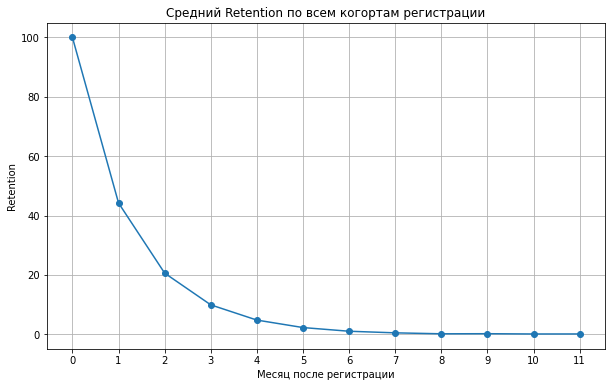

In [18]:
plt.figure(figsize=(10,6))

plt.plot(avg_retention['month'], avg_retention['retention'], marker='o')
    
plt.title('Средний Retention по всем когортам регистрации')
plt.xticks(avg_retention['month'])
plt.xlabel('Месяц после регистрации')
plt.ylabel('Retention')
plt.grid()
plt.show()

In [19]:
print(f"Доля пользователей, которые после регистрации воспользовались продуктом: {round(df_events['user_id'].nunique() / df_users['user_id'].nunique(),4)}")

Доля пользователей, которые после регистрации воспользовались продуктом: 0.5014


Только половина зарегистрированных пользователей в принципе заходили на маркетплейс, не говоря уже о последующих действиях внутри продукта.

#### Денежные метрики

**Заказы по месяцам**

In [20]:
monthly_orders = df_orders.groupby('order_month')['order_id'].nunique().reset_index().rename(columns={'order_id':'total_orders'})

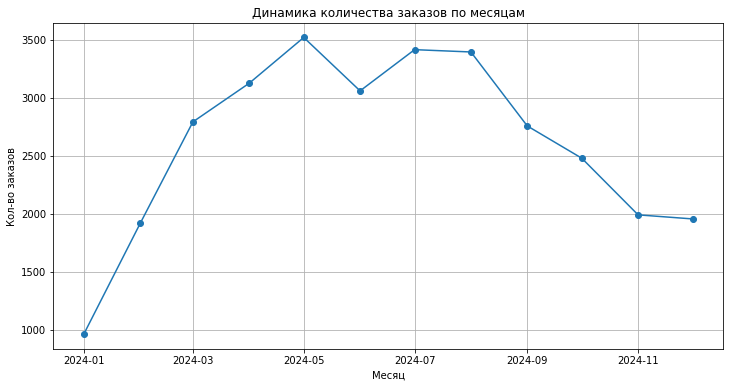

In [21]:
plt.figure(figsize=(12,6))

plt.plot(monthly_orders['order_month'], monthly_orders['total_orders'], marker='o')

plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Кол-во заказов')
plt.grid()
plt.show()

**Конверсия в заказ помесячно**

In [22]:
df_events['event_type'].unique()

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

In [23]:
views = df_events[df_events['event_type'] == 'product_view'][['user_id', 'event_month']].drop_duplicates()
buyers = df_orders[['user_id', 'order_month']].drop_duplicates()
buyers.columns = ['user_id', 'event_month']

cr = views.merge(buyers, on=['user_id', 'event_month'], how='inner')
cr = cr.groupby('event_month')['user_id'].nunique() / views.groupby('event_month')['user_id'].nunique()
cr = cr.reset_index()

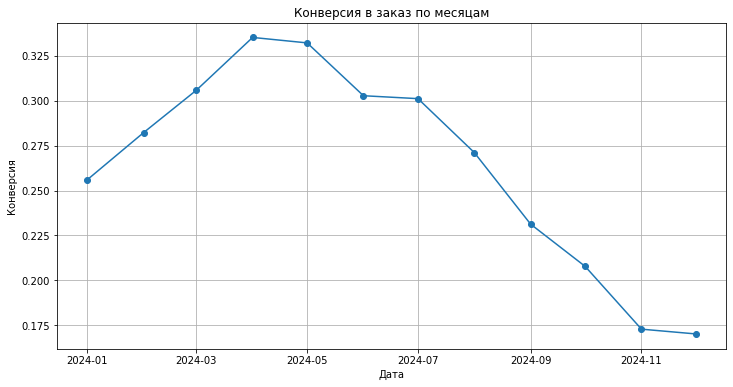

In [24]:
plt.figure(figsize=(12,6))

plt.plot(cr['event_month'], cr['user_id'],marker='o')

plt.title('Конверсия в заказ по месяцам')
plt.ylabel('Конверсия')
plt.xlabel('Дата')

plt.grid()
plt.show()

**Выручка помесячно**

In [25]:
monthly_revenue = df_orders.groupby('order_month')['total_price'].sum().reset_index().rename(columns={'total_price':'total_amount'})
monthly_revenue['total_revenue'] = round((monthly_revenue['total_amount'] * 0.05),2)

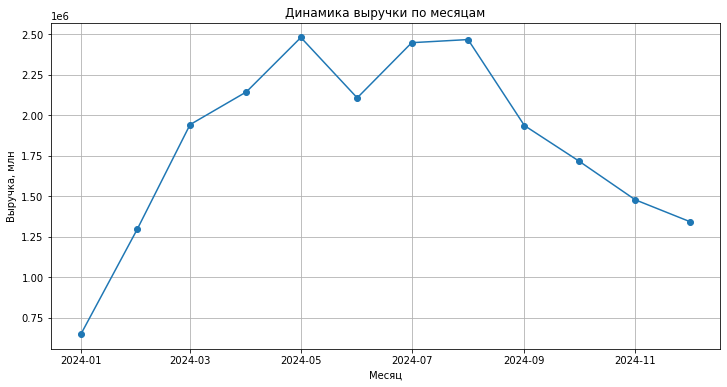

In [26]:
plt.figure(figsize=(12,6))

plt.plot(monthly_revenue['order_month'], monthly_revenue['total_revenue'], marker='o')

plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка, млн')
plt.grid()
plt.show()

**Средний чек**

In [27]:
monthly_aov = monthly_orders.merge(monthly_revenue, on='order_month', how='inner')
monthly_aov['aov'] = round(monthly_aov['total_amount'] / monthly_aov['total_orders'],2)

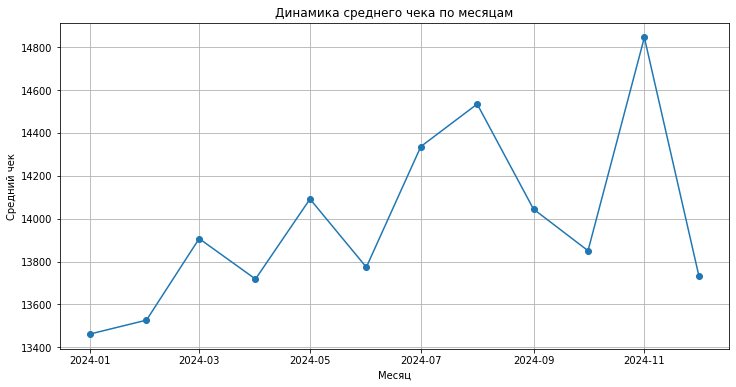

In [28]:
plt.figure(figsize=(12,6))

plt.plot(monthly_aov['order_month'], monthly_aov['aov'], marker='o')

plt.title('Динамика среднего чека по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')
plt.grid()
plt.show()

**ARPU / ARPPU**

In [29]:
monthly_arpu = df_users.groupby('cohort_month')['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})
monthly_arpu = monthly_arpu.merge(monthly_revenue, left_on='cohort_month', right_on='order_month', how='inner')
monthly_arpu['arpu'] = monthly_arpu['total_revenue'] / monthly_arpu['total_users']

In [30]:
monthly_arppu = df_orders.groupby('order_month')['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})
monthly_arppu = monthly_arppu.merge(monthly_revenue, on='order_month', how='inner')
monthly_arppu['arppu'] = monthly_arppu['total_revenue'] / monthly_arppu['total_users']

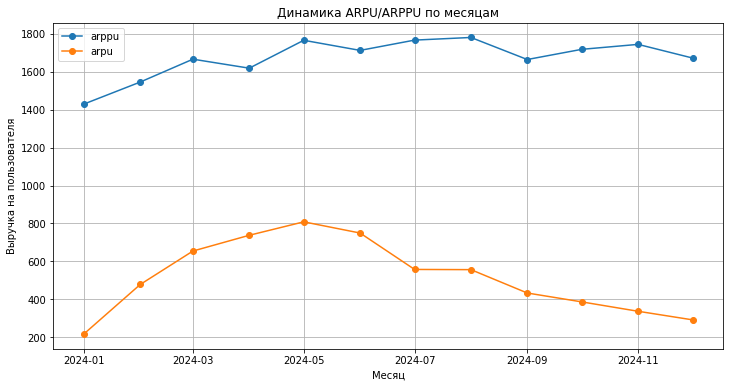

In [31]:
plt.figure(figsize=(12,6))

plt.plot(monthly_arppu['order_month'], monthly_arppu['arppu'], marker='o', label='arppu')
plt.plot(monthly_arpu['order_month'], monthly_arpu['arpu'], marker='o', label='arpu')

plt.title('Динамика ARPU/ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка на пользователя')
plt.legend()
plt.grid()
plt.show()

### Оценка метрик монетизации и юнит-экономики

In [32]:
cac = df_users.groupby(['cohort_month', 'acq_channel'])['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})
cac = cac.merge(df_campaign_costs, left_on=['cohort_month', 'acq_channel'], right_on=['spend_month', 'acq_channel'], how='inner')
cac['cac'] = cac['budget'] / cac['total_users']

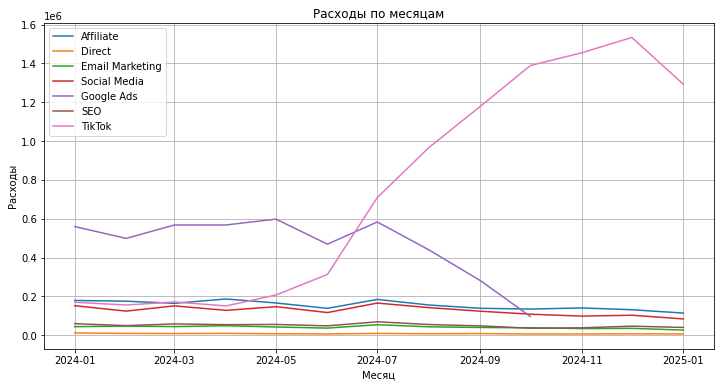

In [33]:
plt.figure(figsize=(12,6))

for channel in df_campaign_costs['acq_channel'].unique():
    df_plot = df_campaign_costs[df_campaign_costs['acq_channel'] == channel]
    plt.plot(df_plot['spend_month'], df_plot['budget'], label=channel)

plt.title('Расходы по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Расходы')
plt.legend()
plt.grid()
plt.show()

В первом полугодии траты на все каналы, кроме Google Ads, составляли не более 200 тыс ежемесячно. С мая расходы на TikTok стали стремительно расти, с июля выводя этот канал на первое место по расходам. В то же время расходы на Google Ads начали сокращаться и финансирование канала прекратилось с ноября. 

In [34]:
df_campaign_costs[df_campaign_costs['acq_channel']=='Google Ads']

,Unnamed: 0,acq_channel,spend_month,budget
48,48,Google Ads,2024-01-01,559875.8125
49,49,Google Ads,2024-02-01,498879.1500
50,50,Google Ads,2024-03-01,567998.5000
51,51,Google Ads,2024-04-01,568075.3125
52,52,Google Ads,2024-05-01,598193.2500
53,53,Google Ads,2024-06-01,469291.9375
54,54,Google Ads,2024-07-01,583428.3125
55,55,Google Ads,2024-08-01,439754.7750
56,56,Google Ads,2024-09-01,281265.7750
57,57,Google Ads,2024-10-01,96726.8250


Не было трат на Google Ads в ноябре и декабре, так как канал был отключен в РФ.

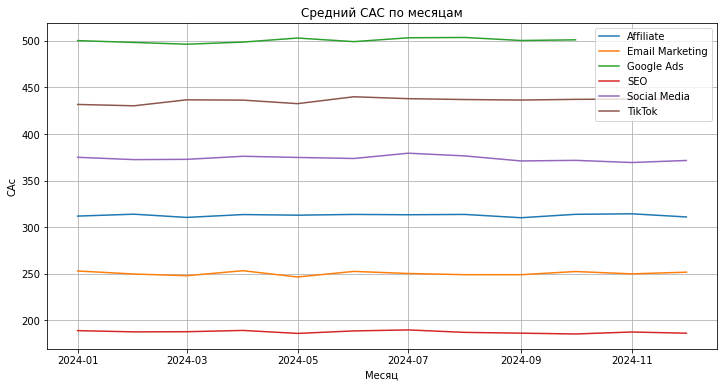

In [35]:
plt.figure(figsize=(12,6))

for channel in cac['acq_channel'].unique():
    df_plot = cac[cac['acq_channel'] == channel]
    plt.plot(df_plot['spend_month'], df_plot['cac'], label=channel)

plt.title('Средний CAC по месяцам')
plt.xlabel('Месяц')
plt.ylabel('CAc')
plt.legend()
plt.grid()
plt.show()

In [36]:
df_campaign_costs['acq_channel'].unique()

array(['Affiliate', 'Direct', 'Email Marketing', 'Social Media',
       'Google Ads', 'SEO', 'TikTok'], dtype=object)

In [37]:
df_users['acq_channel'].unique()

array(['Google Ads', 'Email Marketing', 'Affiliate', 'SEO',
       'Social Media', 'TikTok'], dtype=object)

Канал Direct присутствует в маркетинговых расходах, однако не представлен в пользовательских данных. В связи с этим расчет метрик эффективности (CAC, ROI, Payback Period) для данного канала невозможен, поскольку отсутствует соответствие между затратами и привлеченными пользовтелями.

In [38]:
cac_channel = cac.groupby('acq_channel').agg({
        'budget':'sum',
        'total_users':'sum'
    }).reset_index()


cac_channel['cac'] = cac_channel['budget'] / cac_channel['total_users']

cac_channel = cac_channel.sort_values('cac')

cac_channel

,acq_channel,budget,total_users,cac
3,SEO,6.212539e+05,3312,187.576653
1,Email Marketing,5.117249e+05,2044,250.354637
0,Affiliate,1.898018e+06,6069,312.739778
4,Social Media,1.563229e+06,4179,374.067779
5,TikTok,8.402668e+06,19228,437.001640
2,Google Ads,4.663490e+06,9319,500.428120


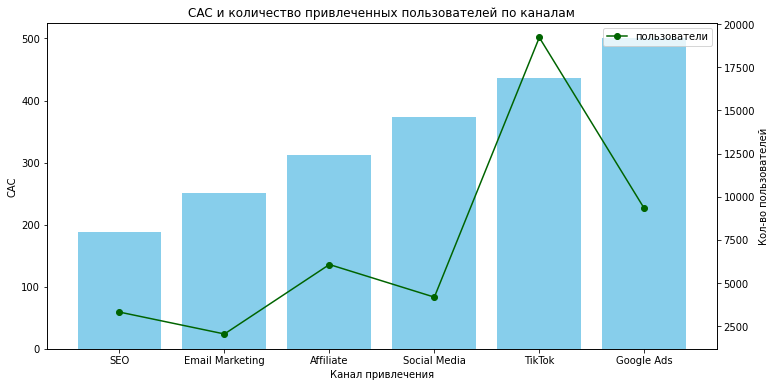

In [39]:
fig, ax1 = plt.subplots(figsize=(12,6))


ax1.bar(cac_channel['acq_channel'], cac_channel['cac'], color='skyblue')

ax1.set_xlabel('Канал привлечения')
ax1.set_ylabel('CAC')

ax2 = ax1.twinx()
ax2.plot(cac_channel['acq_channel'], cac_channel['total_users'], marker='o', color='darkgreen', label='пользователи')

ax2.set_ylabel('Кол-во пользователей')

plt.title('CAC и количество привлеченных пользователей по каналам')
plt.legend()
plt.show()

Здесь так же видно, что наибольшее количество пользователей пришло изTikTok, в то же время CAC этого канала один из самых высоких. 

In [40]:
channel_revenue = df_orders.merge(df_users, on='user_id')
channel_users = df_users.groupby(['acq_channel','cohort_month'])['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})

In [41]:
aov = channel_revenue.groupby(['acq_channel', 'order_month'])['total_price'].mean().reset_index().rename(columns={'total_price':'aov'})
aov['aov'] = round(aov['aov'],2)

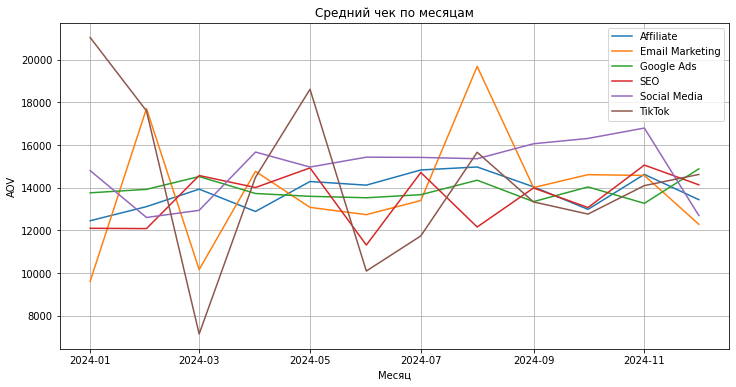

In [42]:
plt.figure(figsize=(12,6))

for channel in aov['acq_channel'].unique():
    df_plot = aov[aov['acq_channel'] == channel]
    plt.plot(df_plot['order_month'], df_plot['aov'], label=channel)

plt.title('Средний чек по месяцам')
plt.xlabel('Месяц')
plt.ylabel('AOV')
plt.legend()
plt.grid()
plt.show()

Стабильно высокий средний чек демонстрируют пользователи, првлеченные через Social Media

In [43]:
arpu = channel_revenue.groupby(['acq_channel','order_month'])['total_price'].sum().reset_index()
arpu = arpu.merge(channel_users, left_on=['acq_channel','order_month'], right_on=['acq_channel','cohort_month'])
arpu['total_revenue'] = arpu['total_price'] *0.05
arpu['arpu'] = round(arpu['total_revenue'] / arpu['total_users'],2)

In [44]:
arppu = channel_revenue.groupby(['acq_channel', 'order_month']).agg({'user_id':'nunique','total_price':'sum'}).reset_index().rename(columns={'user_id':'total_buyers'})
arppu['total_revenue'] = arppu['total_price'] * 0.05
arppu['arppu'] = round(arppu['total_revenue'] / arppu['total_buyers'],2)

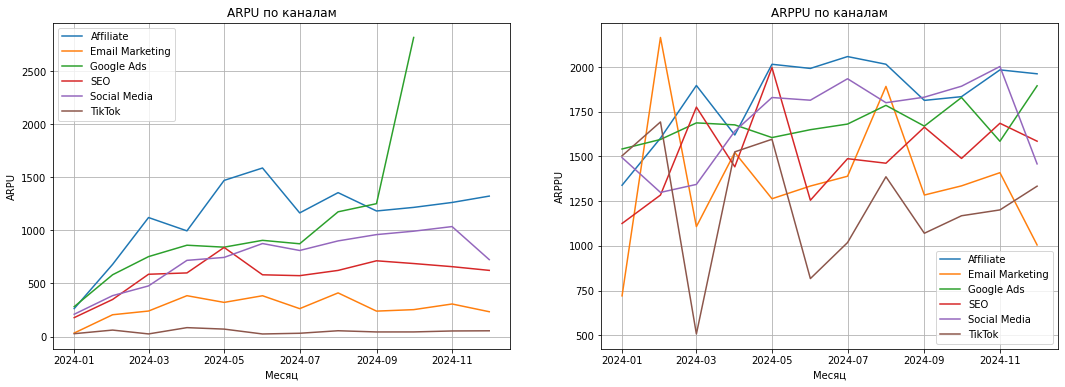

In [45]:
fig, axes = plt.subplots(1,2, figsize=(18,6))

for channel in arpu['acq_channel'].unique():
    df_plot = arpu[arpu['acq_channel']==channel]
    axes[0].plot(df_plot['order_month'], df_plot['arpu'], label=channel)
    
axes[0].set_title('ARPU по каналам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('ARPU')
axes[0].legend()
axes[0].grid()
    
for channel in arppu['acq_channel'].unique():
    df_plot = arppu[arppu['acq_channel']==channel]
    axes[1].plot(df_plot['order_month'], df_plot['arppu'], label=channel)

axes[1].set_title('ARPPU по каналам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('ARPPU')
axes[1].legend()
axes[1].grid()

plt.show()

Лучшие показатели средней выручки на пользователя демонстрируют каналы Affiliate, Social Media и Google Ads (до отключения). Показатели средней выручки на покупателя очень изменчивы на протяжении периода, но также можно выделить лидеров Afiiliate и Social Media.

In [46]:
ltv_data = df_orders.merge(df_users[['user_id','cohort_month','acq_channel']], on='user_id')
ltv_data['lifetime_month'] = (ltv_data['order_month'].dt.year - ltv_data['cohort_month'].dt.year) * 12 + (ltv_data['order_month'].dt.month - ltv_data['cohort_month'].dt.month)

ltv_data = ltv_data.groupby(['cohort_month','acq_channel','lifetime_month'])['total_price'].sum().reset_index()
ltv_data = ltv_data.sort_values(['cohort_month','acq_channel','lifetime_month'])

ltv_data['cum_revenue'] = ltv_data.groupby(['cohort_month','acq_channel'])['total_price'].cumsum()

In [47]:
cohort_size = df_users.groupby(['cohort_month','acq_channel'])['user_id'].nunique().reset_index(name='total_users')

ltv_data = ltv_data.merge(cohort_size, on=['cohort_month','acq_channel'], how='left')

ltv_data['ltv'] = (ltv_data['cum_revenue'] * 0.05) / ltv_data['total_users']

In [48]:
roi = ltv_data.merge(cac[['cohort_month','acq_channel','cac']], on=['cohort_month','acq_channel'])

roi['roi'] = (roi['ltv'] - roi['cac']) / roi['cac']

roi_pivot = roi.pivot_table(
    index='cohort_month',
    columns='acq_channel',
    values='roi'
)

roi_pivot

acq_channel,Affiliate,Email Marketing,Google Ads,SEO,Social Media,TikTok
cohort_month,,,,,,
2024-01-01,1.611836,-0.272442,0.591604,1.575487,0.233721,-0.871454
2024-02-01,2.093199,0.016245,0.474786,1.874181,0.226981,-0.870779
2024-03-01,2.854905,0.049781,0.459768,1.747734,1.231781,-0.936556
2024-04-01,2.175086,0.430359,0.677755,2.322845,0.800846,-0.871742
2024-05-01,3.423267,-0.282844,0.232149,1.537296,0.534435,-0.862526
2024-06-01,2.249109,-0.380954,0.526624,1.507454,0.736715,-0.914025
2024-07-01,1.615887,0.249889,0.475944,1.631385,0.700565,-0.852251
2024-08-01,1.824867,-0.499599,0.352713,0.828267,0.569239,-0.914513
2024-09-01,1.393577,-0.348889,0.055661,1.334426,0.513494,-0.895011


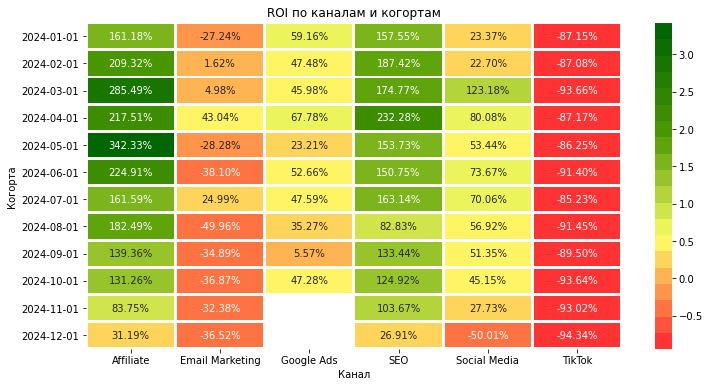

In [49]:
plt.figure(figsize=(12,6))

roi_pivot.index = pd.to_datetime(roi_pivot.index).strftime('%Y-%m-%d')
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

sns.heatmap(
    roi_pivot,
    annot=True,
    cmap=cmap,
    fmt='.2%',
    linewidths=2,
    annot_kws={"size": 10}
)

plt.title('ROI по каналам и когортам')
plt.xlabel('Канал')
plt.ylabel('Когорта')

plt.show()

In [50]:
payback = roi[roi['ltv'] >= roi['cac']].groupby(['cohort_month','acq_channel'])['lifetime_month'].min().reset_index()

payback['payback_period'] = payback['lifetime_month'] + 1

all_cohorts = roi[['cohort_month','acq_channel']].drop_duplicates()

payback = all_cohorts.merge(payback[['cohort_month','acq_channel','payback_period']], on=['cohort_month','acq_channel'], how='left')

payback_pivot = payback.pivot_table(
    index='cohort_month',
    columns='acq_channel',
    values='payback_period'
)

payback_pivot

acq_channel,Affiliate,Email Marketing,Google Ads,SEO,Social Media
cohort_month,,,,,
2024-01-01,2.0,8.0,2.0,2.0,3.0
2024-02-01,2.0,3.0,2.0,2.0,2.0
2024-03-01,1.0,3.0,2.0,1.0,2.0
2024-04-01,2.0,2.0,2.0,1.0,2.0
2024-05-01,1.0,NaN,2.0,1.0,2.0
2024-06-01,1.0,NaN,2.0,2.0,2.0
2024-07-01,2.0,2.0,2.0,1.0,2.0
2024-08-01,1.0,NaN,2.0,2.0,2.0
2024-09-01,2.0,NaN,2.0,1.0,2.0


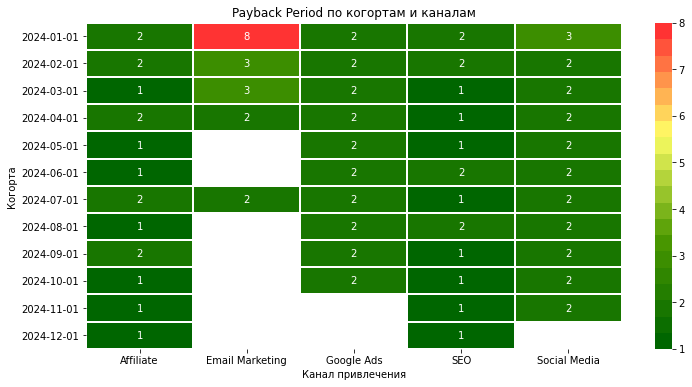

In [51]:
plt.figure(figsize=(12,6))

payback_pivot.index = pd.to_datetime(payback_pivot.index).strftime('%Y-%m-%d')
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#006600', '#4C9900', '#FFFF66', '#FF3333'], N=20)

sns.heatmap(
    payback_pivot,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    linewidths=1
)

plt.title('Payback Period по когортам и каналам')
plt.xlabel('Канал привлечения')
plt.ylabel('Когорта')
plt.show()

Пропуски на тепловой карте означают, что данная когорта не окупилась за весь период наблюдения. Все когорты, привлеченные через TikTok, не окупились на протяжении всего периода.

Email Merketing и TikTok показывают худшие значения ROI и окупаемости среди всех каналов, рассмотрю их период окупаемости:

In [52]:
costs_email = df_campaign_costs[df_campaign_costs['acq_channel']=='Email Marketing'].copy()
costs_email = costs_email.groupby('spend_month')['budget'].sum().reset_index()

cohort_email = df_users[df_users['acq_channel']=='Email Marketing'].groupby('cohort_month')['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})

cac_email = cohort_email.merge(costs_email, left_on='cohort_month', right_on='spend_month')
cac_email['cac'] = cac_email['budget'] / cac_email['total_users']

cohort_revenue_email = df_orders.merge(df_users[['user_id','cohort_month','acq_channel']], on='user_id', how='left')
cohort_revenue_email = cohort_revenue_email[cohort_revenue_email['acq_channel'] == 'Email Marketing']
cohort_revenue_email['lifetime_month'] = (cohort_revenue_email['order_month'].dt.year - cohort_revenue_email['cohort_month'].dt.year) * 12+(cohort_revenue_email['order_month'].dt.month - cohort_revenue_email['cohort_month'].dt.month)
    
cohort_revenue_email = cohort_revenue_email.groupby(['cohort_month', 'lifetime_month'])['total_price'].sum().reset_index()

all_rows = []

for cohort in cohort_revenue_email['cohort_month'].unique():

    max_lifetime = cohort_revenue_email.loc[cohort_revenue_email['cohort_month'] == cohort,'lifetime_month'].max()

    for month in range(int(max_lifetime) + 1):

        all_rows.append({
            'cohort_month': cohort,
            'lifetime_month': month
        })

full_grid = pd.DataFrame(all_rows)

cohort_revenue_email = full_grid.merge(cohort_revenue_email, on=['cohort_month', 'lifetime_month'],how='left')

cohort_revenue_email['total_price'] = cohort_revenue_email['total_price'].fillna(0)

cohort_revenue_email = cohort_revenue_email.sort_values(['cohort_month','lifetime_month'])
cohort_revenue_email['cum_revenue'] = cohort_revenue_email.groupby('cohort_month')['total_price'].cumsum()
cohort_revenue_email['cum_revenue'] = cohort_revenue_email['cum_revenue'] * 0.05
cohort_revenue_email = cohort_revenue_email.merge(cohort_email, on='cohort_month', how='left')

cohort_revenue_email['ltv'] = cohort_revenue_email['cum_revenue'] / cohort_revenue_email['total_users']

In [53]:
cohort_roi_email = pd.merge(cohort_revenue_email, cac_email[['cohort_month','cac']], on='cohort_month')
cohort_roi_email = cohort_roi_email.sort_values(['cohort_month', 'lifetime_month'])

cohort_roi_email['ltv'] = cohort_roi_email['cum_revenue'] / cohort_roi_email['total_users']
cohort_roi_email['roi'] = (cohort_roi_email['ltv'] - cohort_roi_email['cac']) / cohort_roi_email['cac']

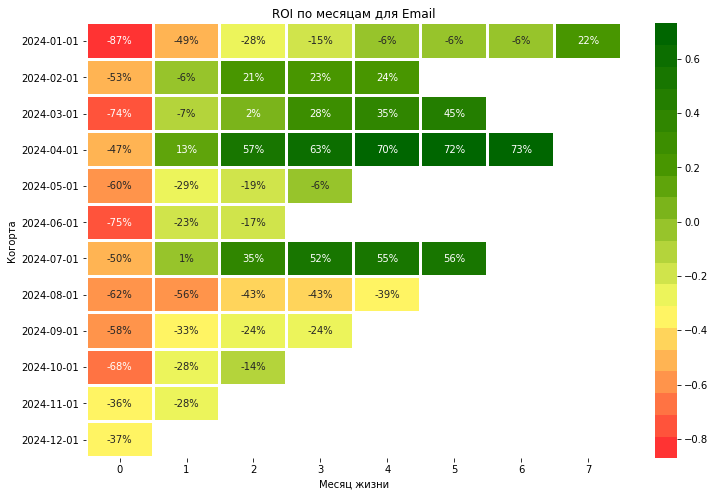

In [54]:
df_pivot = cohort_roi_email.pivot_table(index='cohort_month', columns='lifetime_month', values='roi')

df_pivot[df_pivot == 0] = float('nan')

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

plt.figure(figsize=(12, 8))

df_pivot.index = pd.to_datetime(df_pivot.index).strftime('%Y-%m-%d')

sns.heatmap(df_pivot,
          cmap=cmap,
          annot=True,
          fmt='.0%',
          linewidths=2,
          annot_kws={"size": 10})


plt.title('ROI по месяцам для Email')
plt.xlabel('Месяц жизни')
plt.ylabel('Когорта')
plt.show()

Пропуски на тепловой карте обощначают отсутствие покупок у когорт в данный период (например, когорта июня перестала совершать покупки с августа). Видно, что канал Email у всех когорт не окупается в первый месяц их жизни, причем более ранние когорты окупались быстрее, но начиная с августовской когорты канал не окупается до конца года.

In [55]:
def calc_payback(df):
    df = df.sort_values(['cohort_month','lifetime_month'])

    payback = (
        df.assign(is_payback = df['ltv'] >= df['cac'])
          .groupby('cohort_month')
          .apply(lambda x: x.loc[x['is_payback'], 'lifetime_month'].min())
          .reset_index()
    )

    payback.columns = ['cohort_month', 'lifetime_month']
    payback['payback_period'] = payback['lifetime_month'] + 1

    return payback

In [56]:
payback_email = calc_payback(cohort_roi_email)

payback_email = cohort_roi_email[['cohort_month']].drop_duplicates().merge(payback_email, on='cohort_month', how='left')

payback_email['payback_period'] = payback_email['payback_period'].fillna(0)

In [57]:
payback_email[['cohort_month', 'payback_period']]

,cohort_month,payback_period
0,2024-01-01,8.0
1,2024-02-01,3.0
2,2024-03-01,3.0
3,2024-04-01,2.0
4,2024-05-01,0.0
5,2024-06-01,0.0
6,2024-07-01,2.0
7,2024-08-01,0.0
8,2024-09-01,0.0
9,2024-10-01,0.0


In [58]:
costs_tiktok = df_campaign_costs[df_campaign_costs['acq_channel']=='TikTok'].copy()
costs_tiktok = costs_tiktok.groupby('spend_month')['budget'].sum().reset_index()

cohort_tiktok = df_users[df_users['acq_channel']=='TikTok'].groupby('cohort_month')['user_id'].nunique().reset_index().rename(columns={'user_id':'total_users'})

cac_tiktok = cohort_tiktok.merge(costs_tiktok, left_on='cohort_month', right_on='spend_month')
cac_tiktok['cac'] = cac_tiktok['budget'] / cac_tiktok['total_users']

cohort_revenue_tiktok = df_orders.merge(df_users[['user_id','cohort_month','acq_channel']], on='user_id', how='left')
cohort_revenue_tiktok = cohort_revenue_tiktok[cohort_revenue_tiktok['acq_channel'] == 'TikTok']
cohort_revenue_tiktok['lifetime_month'] = (cohort_revenue_tiktok['order_month'].dt.year - cohort_revenue_tiktok['cohort_month'].dt.year) * 12+(cohort_revenue_tiktok['order_month'].dt.month - cohort_revenue_tiktok['cohort_month'].dt.month)
    
cohort_revenue_tiktok = cohort_revenue_tiktok.groupby(['cohort_month', 'lifetime_month'])['total_price'].sum().reset_index()

all_rows = []

for cohort in cohort_revenue_tiktok['cohort_month'].unique():

    max_lifetime = cohort_revenue_tiktok.loc[cohort_revenue_tiktok['cohort_month'] == cohort,'lifetime_month'].max()

    for month in range(int(max_lifetime) + 1):

        all_rows.append({
            'cohort_month': cohort,
            'lifetime_month': month
        })

full_grid = pd.DataFrame(all_rows)

cohort_revenue_tiktok = full_grid.merge(cohort_revenue_tiktok, on=['cohort_month', 'lifetime_month'],how='left')

cohort_revenue_tiktok['total_price'] = cohort_revenue_tiktok['total_price'].fillna(0)

cohort_revenue_tiktok = cohort_revenue_tiktok.sort_values(['cohort_month','lifetime_month'])
cohort_revenue_tiktok['cum_revenue'] = cohort_revenue_tiktok.groupby('cohort_month')['total_price'].cumsum()
cohort_revenue_tiktok['cum_revenue'] = cohort_revenue_tiktok['cum_revenue'] * 0.05
cohort_revenue_tiktok = cohort_revenue_tiktok.merge(cohort_tiktok, on='cohort_month', how='left')

cohort_revenue_tiktok['ltv'] = cohort_revenue_tiktok['cum_revenue'] / cohort_revenue_tiktok['total_users']

In [59]:
cohort_roi_tiktok = pd.merge(cohort_revenue_tiktok, cac_tiktok[['cohort_month','cac']], on='cohort_month')
cohort_roi_tiktok = cohort_roi_tiktok.sort_values(['cohort_month', 'lifetime_month'])

cohort_roi_tiktok['ltv'] = cohort_roi_tiktok['cum_revenue'] / cohort_roi_tiktok['total_users']
cohort_roi_tiktok['roi'] = (cohort_roi_tiktok['ltv'] - cohort_roi_tiktok['cac']) / cohort_roi_tiktok['cac']

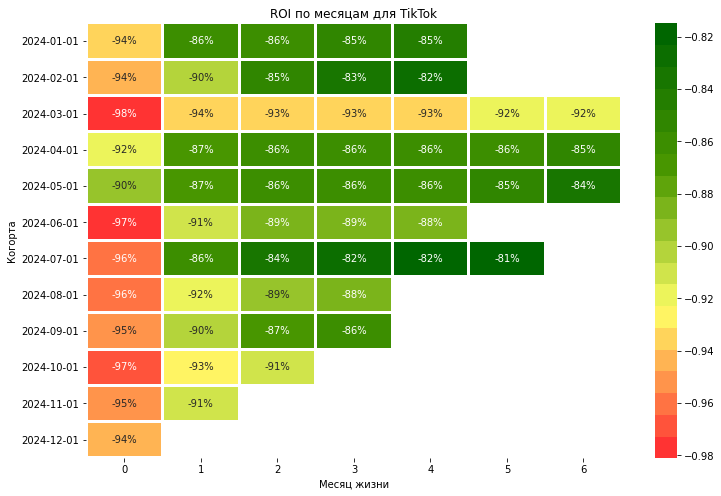

In [60]:
df_pivot = cohort_roi_tiktok.pivot_table(index='cohort_month', columns='lifetime_month', values='roi')

df_pivot[df_pivot == 0] = float('nan')

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

plt.figure(figsize=(12, 8))

df_pivot.index = pd.to_datetime(df_pivot.index).strftime('%Y-%m-%d')

sns.heatmap(df_pivot,
          cmap=cmap,
          annot=True,
          fmt='.0%',
          linewidths=2,
          annot_kws={"size": 10})


plt.title('ROI по месяцам для TikTok')
plt.xlabel('Месяц жизни')
plt.ylabel('Когорта')
plt.show()

Пропуски на тепловой карте обощначают отсутствие покупок у когорт в данный период (например, когорта января перестала совершать покупки с июня). По имеющимся данным, канал TikTok не окупается на протяжении всего периода, что говорит о привлечении трафика низкой ценности, пользователи приходят на маркетплейс, но не совершают покупок.

In [61]:
payback_tiktok = calc_payback(cohort_roi_tiktok)

payback_tiktok = cohort_roi_tiktok[['cohort_month']].drop_duplicates().merge(payback_tiktok, on='cohort_month', how='left')

payback_tiktok['payback_period'] = payback_tiktok['payback_period'].fillna(0)

payback_tiktok[['cohort_month', 'payback_period']]

,cohort_month,payback_period
0,2024-01-01,0.0
1,2024-02-01,0.0
2,2024-03-01,0.0
3,2024-04-01,0.0
4,2024-05-01,0.0
5,2024-06-01,0.0
6,2024-07-01,0.0
7,2024-08-01,0.0
8,2024-09-01,0.0
9,2024-10-01,0.0


<a id="summary1"></a>

## Выводы о состоянии продукта

<b><a href="https://docs.google.com/presentation/d/1wBbSNdd3Le-MRBNWSmU2MHzvvr1YLbrbphLXlp32Knk/edit?usp=sharing" target="_blank">Ссылка на презентацию с основными тезисами исследовательского анализа</a></b>

**Подробная аналитическая записка с выводами:**

#### Оценка состояния продукта

В течение первой половины года маркетплейс демонстрировал положительную динамику практически по всем ключевым метрикам. Набор новой аудитории оставался стабильным на уровне около 100 новых пользователей в день, росли DAU, WAU и MAU, увеличивались количество заказов, выручка, ARPU и ARPPU.

Однако начиная со второй половины года динамика меняется. Несмотря на заметный рост притока новых пользователей в июле и последующие месяцы (до 140–160 пользователей в день), большинство ключевых метрик активности и монетизации начинают снижаться. 

- Количество новых пользователей существенно увеличилось во втором полугодии, особенно после июльского скачка. При этом активная аудитория не расла в том же темпе. DAU, WAU и MAU достигли максимальных значений весной и летом, после чего начал снижаться, пик месячной аудитории был достигнут в августе, после чего начался устойчивый спад.
    
   *Дополнительно отмечу низкую активацию пользователей: только около 50% зарегистрированных пользователей совершают хотя бы одно действие в продукте после регистрации. Это говорит о заметных потерях аудитории уже на первых этапах использования продукта.*
   
   
- Удержание пользователей демонстрирует классический паттерн быстрого раннего оттока: основное снижение активности происходит в первые 1-2 месяца после регистрации. В среднем только 44% пользователей возвращаются в продукт на следующий месяц, по прошествии полугода метрика падает почти до нуля. Также наблюдается постепенное ухудшение качества новых когорт во второй половине года - пользователи, привлеченные позже, демонстрируют более низкие показатели удержания.

    *Низкое долгосрочное удержание пользователей указывает на слабое формирование долгоживущей аудитории.*
  
  
- Конверсия в заказ демонстрирует негативный тренд. Максимальное значение достигнуто в апреле (около 33.5%), далее показатель практически непрерывно снижается и к концу года конверсия составляет около 17%.

    *Снижение почти вдвое при одновременном росте числа регистраций является одним из наиболее тревожных сигналов. Пользователи продолжают приходить в продукт, но реже доходят до покупки.*
    

- Динамика выручки, количества заказов и ARPU практически совпадает: рост в начале года, пик в мае, дальше колебания и устойчивое снижение начиная с сентября. ARPPU показывает схожее поведение, однако достигает максимума в августе, что свидетельствует о росте выручки на одного покупателя в этот период. Средний чек не имеет выраженного тренда, показыавет явные колебания каждый месяц, хотя можно отметить локальные пики в августе и ноябре.


**Вывод**

Продукт показывает тенденцию к росту, особенно во втором полугодии, но существенно набранная аудитория не способствует росту пользовательской активности и доходов маркетплейса.

Тревожные сигналы:
- только половина зарегистрировавшихся пользователей в принциипе использует продукт;
- слабое удержание и ранний отток пользователей;
- количество активных пользователей снижается во втором полугодии;
- конверсия в заказ стремительно падает почти вдвое от пика к концу года;
- монетизация также падает во второй половине года.

#### Оценка юнит-экономики

В первом полугодии траты на все каналы, кроме Google Ads, составляли не более 200 тыс ежемесячно. С мая расходы на TikTok стали стремительно расти, с июля выводя этот канал на первое место по расходам. В то же время расходы на Google Ads начали сокращаться и финансирование канала прекратилось с ноября в связи с прекращением деятельности в РФ. Канал Direct присутствует в маркетинговых расходах, однако не представлен в пользовательских данных. В связи с этим расчет метрик эффективности (CAC, ROI, Payback Period) для данного канала невозможен, поскольку отсутствует соответствие между затратами и привлеченными пользовтелями.

Сравнение стоимости привлечения пользователей (CAC) показало существенные различия между маркетинговыми каналами.

Самый высокий CAC показывали каналы Google Ads (до ноября) и Tiktok. Наиболее низкий CAC наблюдается у каналов SEO и Email Marketing, однако низкая стоимость привлечения сама по себе не гарантирует эффективность канала. Для оценки окупаемости учитывались не только стоимость привлечения, но и качество привлеченых пользователей.

Лучшие показатели средней выручки на пользователя демонстрируют каналы Affiliate, Social Media и Google Ads (до отключения). Показатели средней выручки на покупателя очень изменчивы на протяжении периода, но также можно выделить лидеров Afiiliate и Social Media.

**Вывод**

Наиболее эффективными каналами по совокупности показателей являются Affiliate, SEO и Social Media. Эти каналы демонстрируют хорошие показатели монетизации и положительный ROI.

Самым неэффективным м дорогим каналом привлечения оказался TikTok. Несмотря на значительный объем привлекаемой аудитории показываeт отрицательный ROI на протяжении всего анализируемого периода.

----

## Поиск инсайтов, точек роста и сегментация


Цель данного этапа — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

#### Каналы привлечения пользователей

**Динамика набора аудитории**

In [62]:
channels_dynamic = df_users.groupby(['acq_channel', 'registration_dt'])['user_id'].nunique().reset_index().rename(columns={'user_id':'new_users'})
channels_dynamic = channels_dynamic.sort_values(by=['acq_channel', 'registration_dt'])

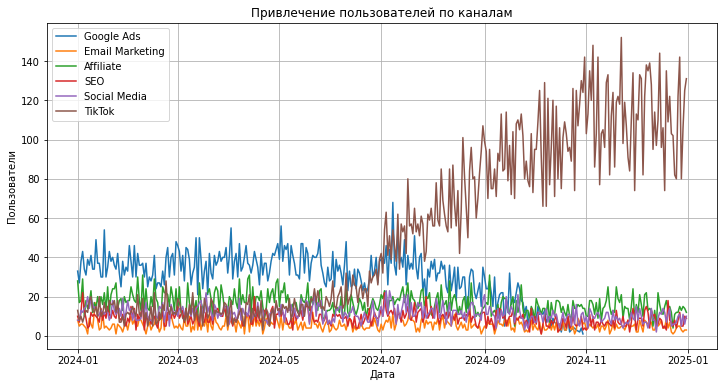

In [63]:
plt.figure(figsize=(12,6))

for channel in df_users['acq_channel'].unique():
    df_plot = channels_dynamic[channels_dynamic['acq_channel']==channel]
    plt.plot(df_plot['registration_dt'], df_plot['new_users'], label=channel)
    
plt.title('Привлечение пользователей по каналам')
plt.xlabel('Дата')
plt.ylabel('Пользователи')
plt.legend()
plt.grid()
plt.show()

На графике видно, что в первом полугодии больше всего пользователей привлекались через канал Google Ads, однако начиная с июля ежедневное количество привлеченных через этот канал пользователей падает, а с ноября канал был отключен. С июля значительный прирост новых пользователей обеспечивал канал TikTok, оставаясь самым масштабным вплоть до конца года. Остальные каналы показывают примерно одинаковые значения на протяжении всего периода.

**Активность пользователей**

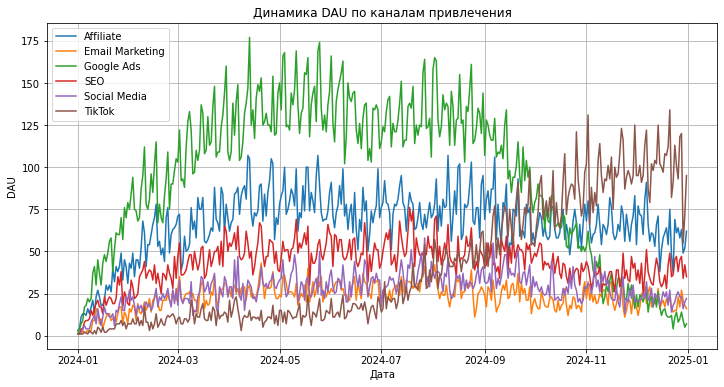

In [64]:
channels_events = df_events.merge(df_users, on='user_id')
channels_dau = channels_events.groupby(['acq_channel','event_date'])['user_id'].nunique().reset_index().rename(columns={'user_id':'dau'})

plt.figure(figsize=(12,6))

for channel in channels_dau['acq_channel'].unique():
    df_plot = channels_dau[channels_dau['acq_channel']==channel]
    plt.plot(df_plot['event_date'], df_plot['dau'], label=channel)

plt.title('Динамика DAU по каналам привлечения')
plt.xlabel('Дата')
plt.ylabel('DAU')
plt.legend()
plt.grid()
plt.show()

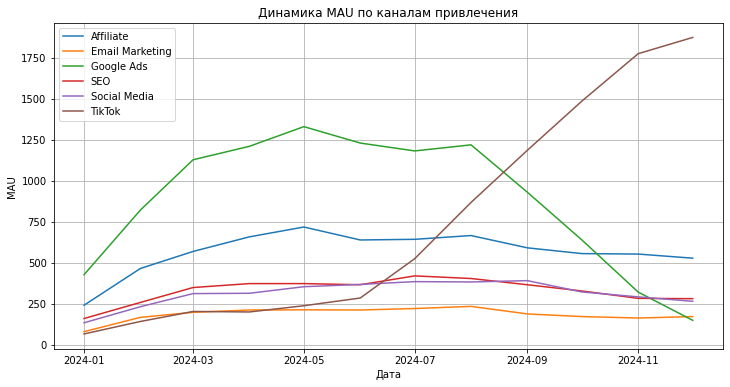

In [65]:
channels_mau = channels_events.groupby(['acq_channel','event_month'])['user_id'].nunique().reset_index().rename(columns={'user_id':'mau'})

plt.figure(figsize=(12,6))

for channel in channels_mau['acq_channel'].unique():
    df_plot = channels_mau[channels_mau['acq_channel']==channel]
    plt.plot(df_plot['event_month'], df_plot['mau'], label=channel)

plt.title('Динамика MAU по каналам привлечения')
plt.xlabel('Дата')
plt.ylabel('MAU')
plt.legend()
plt.grid()
plt.show()

Метрики DAU и MAU в разрезе каналов привлечения демонстрируют, что большую часть года самой активной была аудитория, привлеченная через Google Ads, однако начиная с июля значительно возрастает количество активных пользователй, привлеченных из TikTok несмотря на то что с января по апрель этот канал демонстрировал самые низкие показатели активной аудитории из всех. Канал Email Marketing на протяжении всего периода остается одним из самых слабых, с мая занимая самую низкую позицию по активности привлеченных пользователей. Для других каналов метрика остается относительно стабильной за весь период.

In [66]:
channels_events.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,registration_dt
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01,2024-01-01 03:51:00,39,M,Другие регионы,Affiliate,regular,2024-01-01,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01,2024-01-01 03:51:00,39,M,Другие регионы,Affiliate,regular,2024-01-01,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01,2024-01-01 03:51:00,39,M,Другие регионы,Affiliate,regular,2024-01-01,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01,2024-01-01 03:51:00,39,M,Другие регионы,Affiliate,regular,2024-01-01,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01,2024-01-01 03:51:00,39,M,Другие регионы,Affiliate,regular,2024-01-01,2024-01-01,2024-01-01


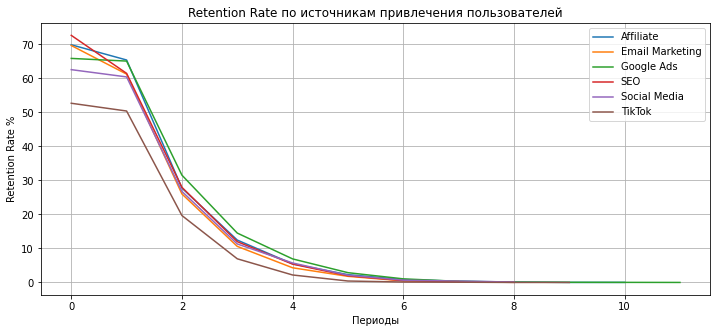

In [67]:
retention_data = channels_events.copy()
retention_data['n_period'] = retention_data['event_month'].dt.to_period('M').astype('int64') - retention_data['cohort_month'].dt.to_period('M').astype('int64')

table1 =  retention_data.groupby('acq_channel')['user_id'].nunique().reset_index()
table1.rename(columns={'user_id':'total_user_count'}, inplace=True)

table2 = retention_data.groupby(['acq_channel','n_period'])['user_id'].nunique().reset_index()
table2.rename(columns={'user_id':'period_user_count'}, inplace=True)

table_final = pd.merge(table2, table1, how='left', on='acq_channel')
table_final['retention'] = table_final['period_user_count'] / table_final['total_user_count'] * 100

plt.figure(figsize=(12,5))
for channel in table_final['acq_channel'].unique():
    plt.plot (table_final[table_final['acq_channel']==channel]['n_period'], table_final[table_final['acq_channel']==channel]['retention'])
    
plt.title('Retention Rate по источникам привлечения пользователей')
plt.legend(table_final['acq_channel'].unique())
plt.xlabel('Периоды')
plt.ylabel('Retention Rate %')
plt.grid()
plt.show()

Несмотря на высокую ежедневную и ежемесячную активность привлеченных пользователей во втором полугодии, канал TikTok показывает самое низкое удержание пользователей среди всех каналов, у которых показатель удержания примерно одинаковый (Google Ads "держит" пользователей чуть лучше в поздних периодах)

**Конверсия в заказ**

In [68]:
product_view_channels = df_events[df_events['event_type']=='product_view'].copy()
product_view_channels = product_view_channels.merge(df_users, on='user_id')
product_view_channels = product_view_channels.groupby(['acq_channel','event_month'])['user_id'].nunique()
buyers_channels = df_orders.merge(df_users, on='user_id')
buyers_channels = buyers_channels.groupby(['acq_channel','order_month'])['user_id'].nunique()

monthly_cr_channels = pd.concat([product_view_channels, buyers_channels], axis=1)
monthly_cr_channels.columns = ['product_view_users', 'buyers']
monthly_cr_channels['cr'] = monthly_cr_channels['buyers'] / monthly_cr_channels['product_view_users']
monthly_cr_channels = monthly_cr_channels.reset_index().rename(columns={'level_1':'month'})

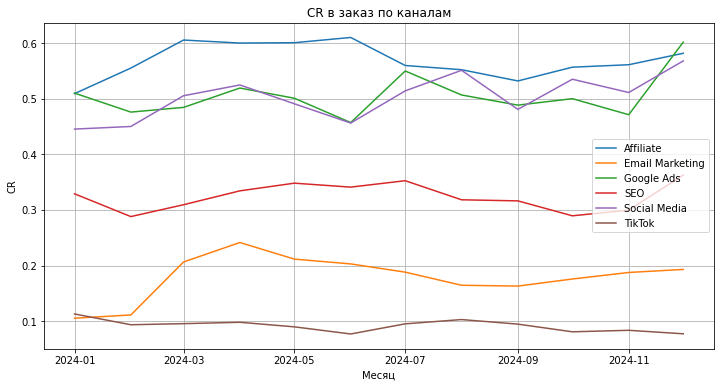

In [69]:
plt.figure(figsize=(12,6))

for channel in monthly_cr_channels['acq_channel'].unique():
    df_plot = monthly_cr_channels[monthly_cr_channels['acq_channel']==channel]
    plt.plot(df_plot['month'], df_plot['cr'], label=channel)

plt.title('CR в заказ по каналам')
plt.xlabel('Месяц')
plt.ylabel('CR')
plt.legend()
plt.grid()
plt.show()

Несмотря на высокую активность, пользователи привлеченные через канал TikTok хуже всего конвертируются из просмотров товаров в заказ.  Самую высокую конверсию в течение всего года показывает канал Affiliate, так же в топ-3 входят Social Media и Google Ads.

Динамика ARPU И ARPPU подтверждает, что канал TikTok приводит много низкокачественного трафика, который не монетизируется, поэтому на обоих графиках канал демонстрирует худшие показатели. Стабильно на верхних позициях держатся каналы Affiliate и Social Media. Скачок ARPU у Google Ads с октября связан с отключением канала и отсутствием привлечченных пользователей в конце года, однако в эти месяцы покупки могли совершать пользователи, привлеченные ранее через этот канал.

#### Сегменты пользователей

In [70]:
df_users['buyer_segment'].unique()

array(['regular', 'rare', 'one_time', 'medium'], dtype=object)

Сегменты выделены по частоте покупок пользователей

In [71]:
users_segments = df_users.groupby('buyer_segment')['user_id'].nunique().reset_index()
users_segments

,buyer_segment,user_id
0,medium,16421
1,one_time,6701
2,rare,13256
3,regular,7773


**Денежные метрики**

In [72]:
segments = df_orders.merge(df_users[['user_id','buyer_segment']], on='user_id')
segment_metrics = segments.groupby('buyer_segment').agg(
        users=('user_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum'),
        aov=('total_price', 'mean')
    ).reset_index()

segment_metrics['orders_per_user'] = segment_metrics['orders'] / segment_metrics['users']
segment_metrics['revenue'] = segment_metrics['revenue'] * 0.05
segment_metrics['arppu'] = round(segment_metrics['revenue'] / segment_metrics['users'],2)

segment_metrics

,buyer_segment,users,orders,revenue,aov,orders_per_user,arppu
0,medium,3692,7528,5.190508e+06,13789.871756,2.039003,1405.88
1,one_time,258,345,2.210517e+05,12814.591623,1.337209,856.79
2,rare,988,1501,1.046910e+06,13949.497715,1.519231,1059.63
3,regular,3716,21072,1.489044e+07,14132.917814,5.670614,4007.12


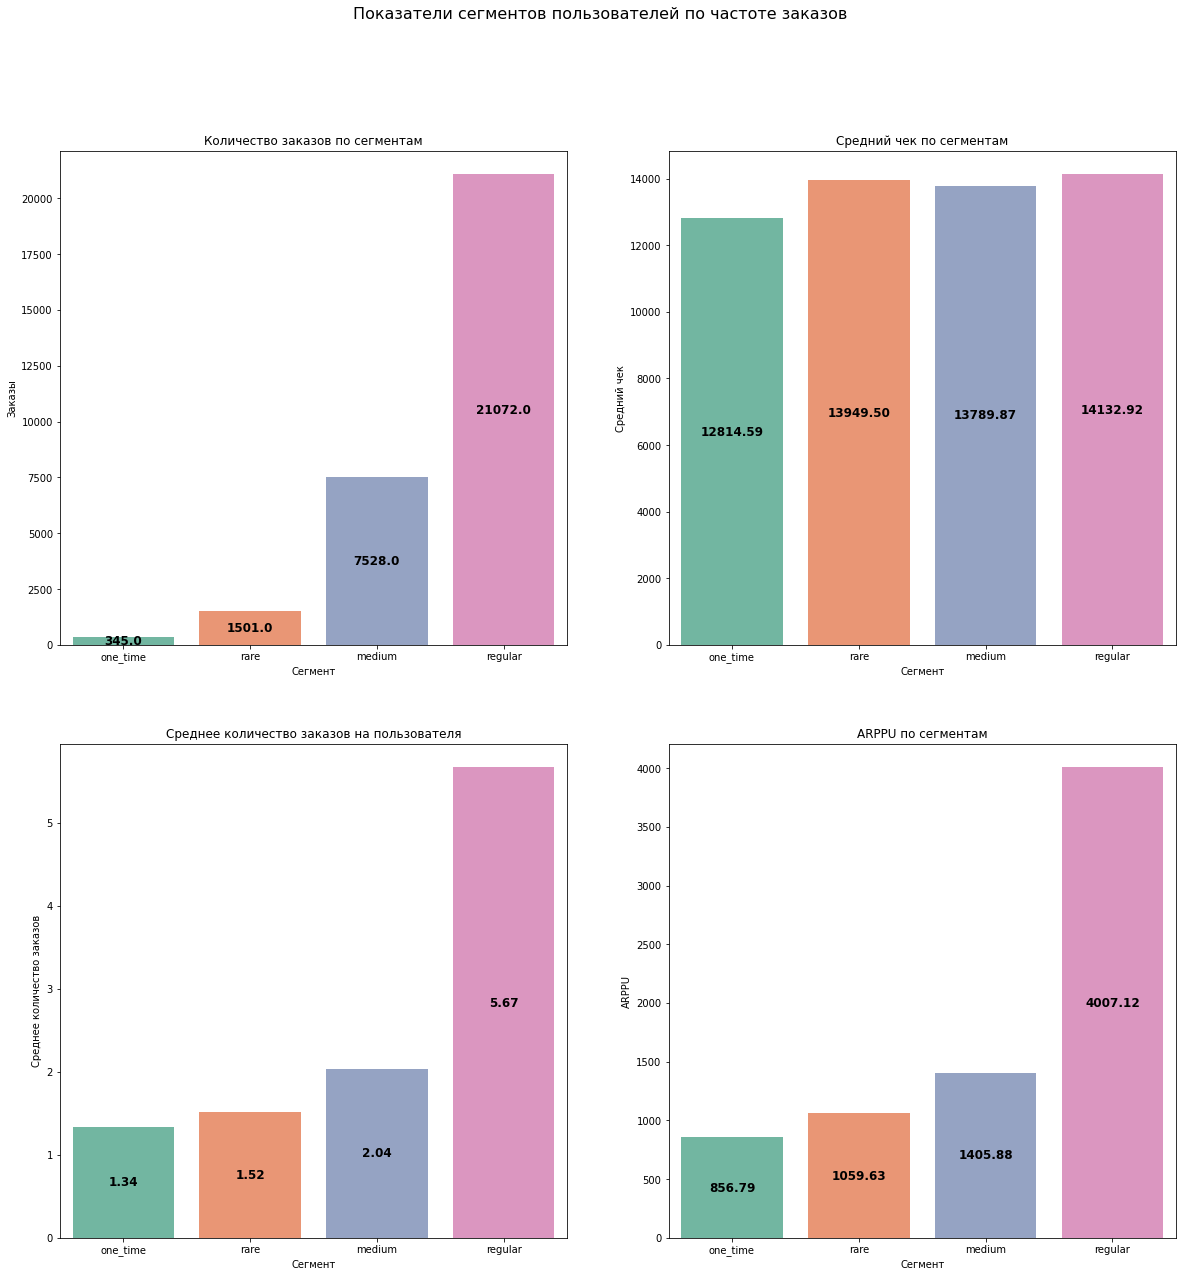

In [73]:
segment_metrics = segment_metrics.sort_values(by='orders_per_user')

fig, axes = plt.subplots(2,2, figsize=(20,20))

sns.barplot(data=segment_metrics, x='buyer_segment', y='orders', palette='Set2', ax=axes[0,0])

for patch in axes[0,0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0,0].text(
        x,
        y,
        height,
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0,0].set_title('Количество заказов по сегментам') 
axes[0,0].set_xlabel('Сегмент')
axes[0,0].set_ylabel('Заказы')

sns.barplot(data=segment_metrics, x='buyer_segment', y='aov', palette='Set2', ax=axes[0,1])

for patch in axes[0,1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0,1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0,1].set_title('Средний чек по сегментам') 
axes[0,1].set_xlabel('Сегмент')
axes[0,1].set_ylabel('Средний чек')

sns.barplot(data=segment_metrics, x='buyer_segment', y='orders_per_user', palette='Set2', ax=axes[1,0])

for patch in axes[1,0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1,0].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1,0].set_title('Среднее количество заказов на пользователя') 
axes[1,0].set_xlabel('Сегмент')
axes[1,0].set_ylabel('Среднее количество заказов')

sns.barplot(data=segment_metrics, x='buyer_segment', y='arppu', palette='Set2', ax=axes[1,1])

for patch in axes[1,1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1,1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1,1].set_title('ARPPU по сегментам') 
axes[1,1].set_xlabel('Сегмент')
axes[1,1].set_ylabel('ARPPU')

plt.suptitle('Показатели сегментов пользователей по частоте заказов', fontsize=16)
plt.show()

На графиках видно, что средний чек между категориями покупателей практически не отличается и находтся в диапазоне от 12.8 тыс до 14.1 тыс, в то время как общее количество заказов и среднее количество заказов на пользователя значительно отличается по сегментам. Большую часть выручки приносят покупатели сегмента regular, за счет частоты покупок ARPPU при не сильно выделяющемся среднем чеке более чем в два раза выше, чем у соседней категории medium.

#### География пользователей

In [74]:
df_users['region'].unique()

array(['Москва', 'Санкт-Петербург', 'Краснодар', 'Другие регионы',
       'Нижний Новгород', 'Екатеринбург', 'Московская область',
       'Новосибирск', 'Ростов-на-Дону'], dtype=object)

In [75]:
users_regions = df_users.groupby('region')['user_id'].nunique().reset_index()
users_regions = users_regions.sort_values(by='user_id', ascending=False)

In [76]:
orders_regions = df_orders.merge(df_users[['user_id','region']], on='user_id')
orders_regions = orders_regions.groupby('region')['order_id'].nunique().reset_index()
orders_regions = orders_regions.sort_values(by='order_id', ascending=False)

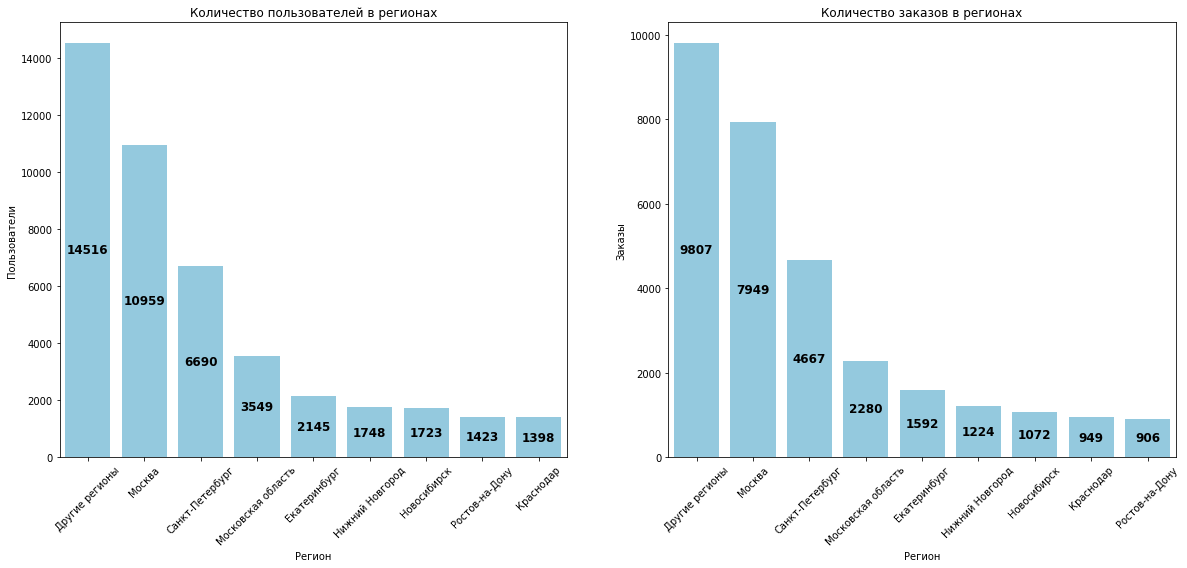

In [77]:
fig, axes= plt.subplots(1,2,figsize=(20,8))

sns.barplot(data=users_regions, x='region', y='user_id', color='skyblue', ax=axes[0])

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.0f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0].set_title('Количество пользователей в регионах')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Пользователи')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=orders_regions, x='region', y='order_id', color='skyblue', ax=axes[1])

for patch in axes[1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.0f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1].set_title('Количество заказов в регионах')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Заказы')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

Распределение пользователей и заказов по регионам практически одинаковое. Самые многочисленные по пользователям и заказам - другие регионы, в данных агрегированные в одну категорию. Среди явно обозначенных городов лидерами являются Москва, Санкт-Петербург и Московская область. Меньше всего пользователей и заказов в Ростове-на-Дону и Краснодаре, причем по заказам Ростов-на-Дону уступает Краснодару несмотря на то, что пользователей оттуда немного больше.

**Денежные метрики**

In [78]:
regions_revenue = df_orders.merge(df_users[['user_id','region']], on='user_id')
regions_revenue = regions_revenue.groupby('region').agg(
    total_amount=('total_price','sum'), 
    aov=('total_price','mean')
).reset_index()
regions_revenue['total_revenue'] = regions_revenue['total_amount'] * 0.05
regions_revenue = regions_revenue.sort_values(by='total_revenue', ascending=False)
regions_revenue

,region,total_amount,aov,total_revenue
0,Другие регионы,1.367472e+08,13943.838727,6.837361e+06
3,Москва,1.082037e+08,13612.238395,5.410184e+06
8,Санкт-Петербург,6.792585e+07,14554.500000,3.396293e+06
4,Московская область,3.317228e+07,14549.245776,1.658614e+06
1,Екатеринбург,2.287532e+07,14368.918335,1.143766e+06
5,Нижний Новгород,1.682844e+07,13748.725523,8.414220e+05
2,Краснодар,1.457675e+07,15360.118746,7.288376e+05
6,Новосибирск,1.457458e+07,13595.691306,7.287291e+05
7,Ростов-на-Дону,1.207410e+07,13326.816623,6.037048e+05


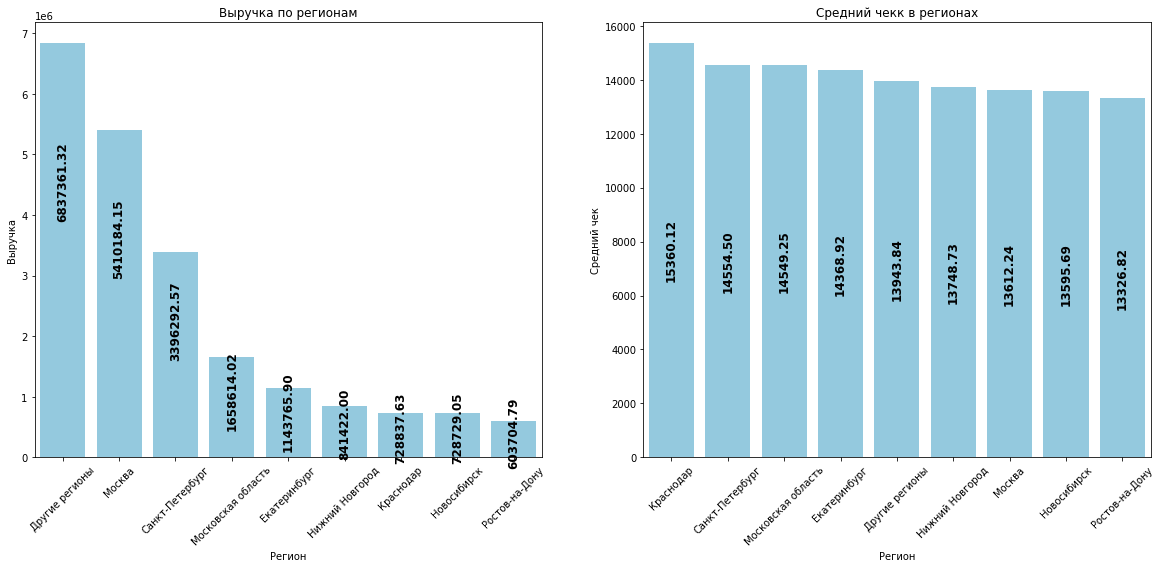

In [79]:
fig, axes= plt.subplots(1,2,figsize=(20,8))

sns.barplot(data=regions_revenue, x='region', y='total_revenue', color='skyblue', ax=axes[0])

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 1.5
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        rotation=90,
        fontweight='bold'
    )
    
axes[0].set_title('Выручка по регионам')
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Выручка')
axes[0].tick_params(axis='x', rotation=45)

regions_revenue = regions_revenue.sort_values(by='aov', ascending=False)

sns.barplot(data=regions_revenue, x='region', y='aov', color='skyblue', ax=axes[1])

for patch in axes[1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        rotation=90,
        fontweight='bold'
    )
    
axes[1].set_title('Средний чекк в регионах')
axes[1].set_xlabel('Регион')
axes[1].set_ylabel('Средний чек')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

Наибольшее количество выручки формируют агрегированные другие регионы, за их исключением топ-3 региона по выручке аналогичны топ-3 регионам по пользователям. Средний чек в регионах различается слабо (максимум 15360 в Краснодаре и минимум 13326 в РнД), из-за этого можно сделать вывод, что выручка в регионах напрямую связана с размером аудитории и не зависит от пользовательского поведеня.

**Конверсия в заказ**

In [80]:
product_view_regions = df_events[df_events['event_type']=='product_view'].copy()
product_view_regions = product_view_regions.merge(df_users[['user_id','region']], on='user_id')
product_view_regions = product_view_regions.groupby(['region','event_month'])['user_id'].nunique()
buyers_regions = df_orders.merge(df_users[['user_id','region']], on='user_id')
buyers_regions = buyers_regions.groupby(['region','order_month'])['user_id'].nunique()

monthly_cr_regions = pd.concat([product_view_regions, buyers_regions], axis=1)
monthly_cr_regions.columns = ['product_view_users', 'buyers']
monthly_cr_regions['cr'] = monthly_cr_regions['buyers'] / monthly_cr_regions['product_view_users']
monthly_cr_regions = monthly_cr_regions.reset_index().rename(columns={'level_1':'month'})

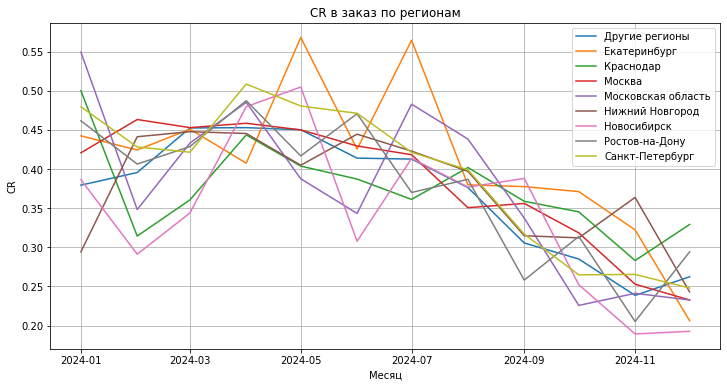

In [81]:
plt.figure(figsize=(12,6))

for region in monthly_cr_regions['region'].unique():
    df_plot = monthly_cr_regions[monthly_cr_regions['region']==region]
    plt.plot(df_plot['month'], df_plot['cr'], label=region)

plt.title('CR в заказ по регионам')
plt.xlabel('Месяц')
plt.ylabel('CR')
plt.legend()
plt.grid()
plt.show()

In [82]:
monthly_cr_regions = monthly_cr_regions.groupby('region')['cr'].mean().reset_index()
monthly_cr_regions = monthly_cr_regions.sort_values(by='cr', ascending=False)
monthly_cr_regions

,region,cr
1,Екатеринбург,0.411598
8,Санкт-Петербург,0.391986
3,Москва,0.383564
5,Нижний Новгород,0.377527
4,Московская область,0.375313
7,Ростов-на-Дону,0.374885
2,Краснодар,0.374004
0,Другие регионы,0.368655
6,Новосибирск,0.343787


С точки зрения конверсии регионы так же ведут себя похожим образом в динамике, а так же разница между максимальной средней конверсией в Екатеринбурге и минимальной средней конверсией в Новосибирске составляет 7%

#### Устройства пользователей

In [83]:
device_users = df_events.groupby('device')['user_id'].nunique().reset_index(name='total_users')
device_users['ratio'] = round(device_users['total_users'] / device_users['total_users'].sum(),2)
device_users

,device,total_users,ratio
0,desktop,7447,0.34
1,mobile,7431,0.34
2,tablet,7260,0.33


Среди пользователей, пользующихся маркетплейсом, примерно равные доли испольщуют версии приложения как десктоп, так и мобильную, и для планшетов.

**Конверсия в заказ**

In [84]:
product_view_devices = df_events[df_events['event_type']=='product_view'].copy()
product_view_devices = product_view_devices.groupby(['device','event_month'])['user_id'].nunique()
buyers_devices = df_orders.merge(df_events[['user_id','device']].drop_duplicates(), on='user_id')
buyers_devices = buyers_devices.groupby(['device','order_month'])['user_id'].nunique()

monthly_cr_devices = pd.concat([product_view_devices, buyers_devices], axis=1)
monthly_cr_devices.columns = ['product_view_users', 'buyers']
monthly_cr_devices['cr'] = monthly_cr_devices['buyers'] / monthly_cr_devices['product_view_users']
monthly_cr_devices = monthly_cr_devices.reset_index().rename(columns={'level_1':'month'})

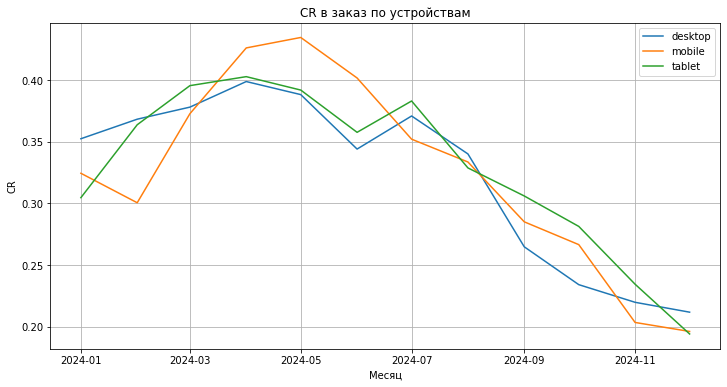

In [85]:
plt.figure(figsize=(12,6))

for device in monthly_cr_devices['device'].unique():
    df_plot = monthly_cr_devices[monthly_cr_devices['device']==device]
    plt.plot(df_plot['month'], df_plot['cr'], label=device)

plt.title('CR в заказ по устройствам')
plt.xlabel('Месяц')
plt.ylabel('CR')
plt.legend()
plt.grid()
plt.show()

In [86]:
monthly_cr_devices = monthly_cr_devices.groupby('device')['cr'].mean().reset_index()
monthly_cr_devices = monthly_cr_devices.sort_values(by='cr', ascending=False)
monthly_cr_devices

,device,cr
2,tablet,0.328698
1,mobile,0.324780
0,desktop,0.322651


На графике существенных различий в конверсии пользователей нет. Средняя конверсия в заказ для desktop, mobile и tablet находится на примерно одинаковом уровне (32–33%), а динамика метрики по месяцам для всех устройств практически совпадает. Небольшой рост конверсии мобильных пользователей наблюдался в период с апреля по июнь, однако во втором полугодии показатели вновь выровнялись.

**Денежные метрики**

In [87]:
df_events.groupby('user_id')['device'].nunique().value_counts()

1    22138
Name: device, dtype: int64

In [88]:
aov_devices = df_orders.merge(df_events[['user_id','device']].drop_duplicates(),on='user_id').groupby('device').agg(
        users=('user_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum'),
        aov=('total_price', 'mean')
    ).reset_index()

aov_devices['orders_per_user'] = aov_devices['orders'] / aov_devices['users']
aov_devices['revenue'] = aov_devices['revenue'] * 0.05
aov_devices['arppu'] = round(aov_devices['revenue'] / aov_devices['users'],2)

aov_devices

,device,users,orders,revenue,aov,orders_per_user,arppu
0,desktop,2428,9247,6.547252e+06,14160.813928,3.808484,2696.56
1,mobile,2493,9485,6.678643e+06,14082.536168,3.804653,2678.96
2,tablet,2377,9677,6.795250e+06,14044.125760,4.071098,2858.75


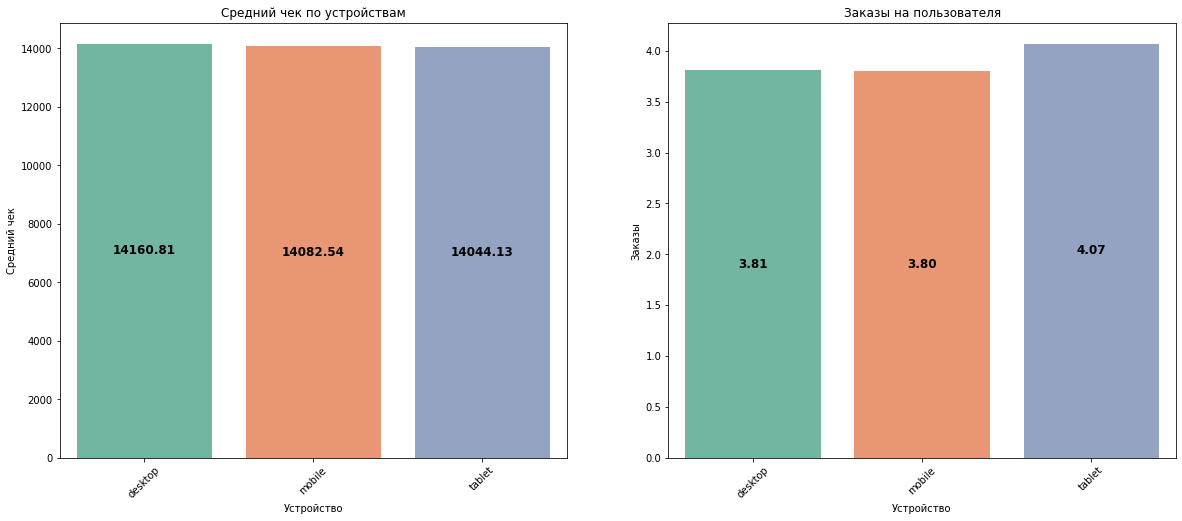

In [89]:
fig, axes= plt.subplots(1,2,figsize=(20,8))

sns.barplot(data=aov_devices, x='device', y='aov', palette='Set2', ax=axes[0])

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0].set_title('Средний чек по устройствам')
axes[0].set_xlabel('Устройство')
axes[0].set_ylabel('Средний чек')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=aov_devices, x='device', y='orders_per_user', palette='Set2', ax=axes[1])

for patch in axes[1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1].set_title('Заказы на пользователя')
axes[1].set_xlabel('Устройство')
axes[1].set_ylabel('Заказы')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

Пользователи планшетов демонстрируют немного более высокую частоту заказов и ARPPU, однако различия остаются незначительными.

#### Категории товаров

In [90]:
category_metrics = df_orders.groupby('category_name').agg(
        buyers=('user_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum'),
        aov=('total_price', 'mean')
    ).reset_index()

category_metrics['revenue'] = category_metrics['revenue'] * 0.05
category_metrics['aov'] = round(category_metrics['aov'],2)
category_metrics['orders_per_user'] = round(category_metrics['orders'] / category_metrics['buyers'],2)
category_metrics['arppu'] = round(category_metrics['revenue'] / category_metrics['buyers'],2)

category_metrics

,category_name,buyers,orders,revenue,aov,orders_per_user,arppu
0,Автотовары,561,1043,1.044822e+06,20034.93,1.86,1862.43
1,Аксессуары для гаджетов,726,1255,6.934703e+05,11051.32,1.73,955.19
2,Бытовая техника,546,1030,2.248933e+06,43668.60,1.89,4118.93
3,Декор и освещение,538,1053,7.038036e+05,13367.59,1.96,1308.19
4,Детская одежда,942,1421,3.213053e+05,4522.24,1.51,341.09
5,Детские игрушки,558,1131,4.350888e+05,7693.88,2.03,779.73
6,Женская одежда,646,1191,6.873350e+05,11542.15,1.84,1063.99
7,Зоотовары,888,1396,3.725840e+05,5337.88,1.57,419.58
8,Инструменты и садовый инвентарь,501,1000,8.123728e+05,16247.46,2.00,1621.50
9,Книги и канцтовары,739,1316,2.044434e+05,3107.04,1.78,276.65


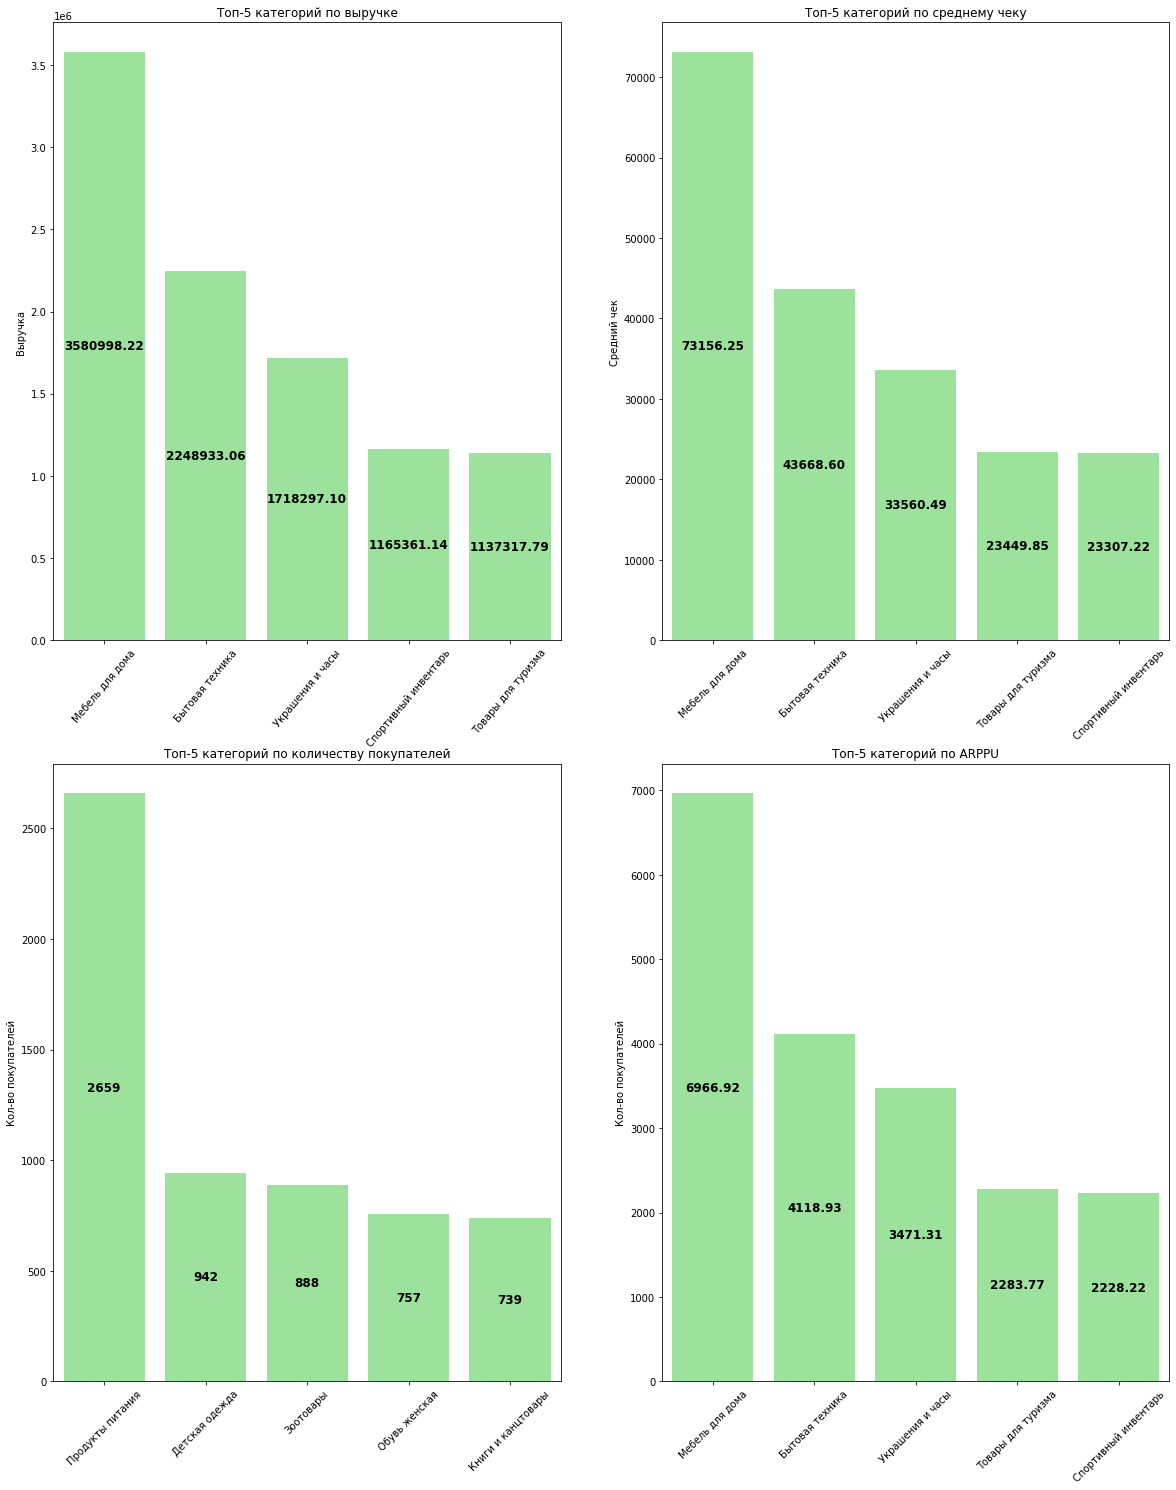

In [91]:
fig, axes= plt.subplots(2,2,figsize=(20,25))

top_5_revenue = category_metrics.sort_values(by='revenue', ascending=False).head(5)

sns.barplot(data=top_5_revenue, x='category_name', y='revenue', color='lightgreen', ax=axes[0,0])

for patch in axes[0,0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0,0].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0,0].set_title('Топ-5 категорий по выручке')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Выручка')
axes[0,0].tick_params(axis='x', rotation=50)

top_5_aov = category_metrics.sort_values(by='aov', ascending=False).head(5)

sns.barplot(data=top_5_aov, x='category_name', y='aov', color='lightgreen', ax=axes[0,1])

for patch in axes[0,1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0,1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[0,1].set_title('Топ-5 категорий по среднему чеку')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Средний чек')
axes[0,1].tick_params(axis='x', rotation=45)

top_5_buyers = category_metrics.sort_values(by='buyers', ascending=False).head(5)

sns.barplot(data=top_5_buyers, x='category_name', y='buyers', color='lightgreen', ax=axes[1,0])

for patch in axes[1,0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1,0].text(
        x,
        y,
        f'{height:.0f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1,0].set_title('Топ-5 категорий по количеству покупателей')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Кол-во покупателей')
axes[1,0].tick_params(axis='x', rotation=45)

top_5_arppu = category_metrics.sort_values(by='arppu', ascending=False).head(5)

sns.barplot(data=top_5_arppu, x='category_name', y='arppu', color='lightgreen', ax=axes[1,1])

for patch in axes[1,1].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1,1].text(
        x,
        y,
        f'{height:.2f}',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
axes[1,1].set_title('Топ-5 категорий по ARPPU')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Кол-во покупателей')
axes[1,1].tick_params(axis='x', rotation=45)

plt.show()

Основную выручку продукту приносят категории мебели для дома, бытовой техники и украшений с часами. Также эти категории демонстрируют самые высокие значения среднего чека и ARPPU (ценность отдельного покупателя). Наиболее массовой категорией являются продукты питания, которые привлекают почти в три раза больше покупателей, чем любая другая категория. Однако данная категория характеризуется самым низким средним чеком и одной из самых низких выручек на покупателя.

#### Пользовательский путь

In [92]:
df_events['event_type'].unique()

array(['page_view', 'product_view', 'product_click', 'add_to_cart',
       'checkout_start', 'checkout_complete', 'user_logout', 'search',
       'category_view', 'filter_apply', 'promo_view', 'wishlist_add',
       'user_login', 'banner_click', 'remove_from_cart'], dtype=object)

In [93]:
funnel_steps = ['product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

funnel_users = []

for step in funnel_steps:
    users_count = df_events[df_events['event_type'] == step]['user_id'].nunique()
    funnel_users.append(users_count)

funnel_users.append(df_orders['user_id'].nunique())

funnel_df = pd.DataFrame({
    'step': funnel_steps + ['order'],
    'users': funnel_users
})

funnel_df['classic_cr_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['cr_previous_step_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

funnel_df

,step,users,classic_cr_%,cr_previous_step_%
0,product_view,22069,100.0,NaN
1,add_to_cart,20411,92.5,92.5
2,checkout_start,16769,76.0,82.2
3,checkout_complete,13897,63.0,82.9
4,order,8922,40.4,64.2


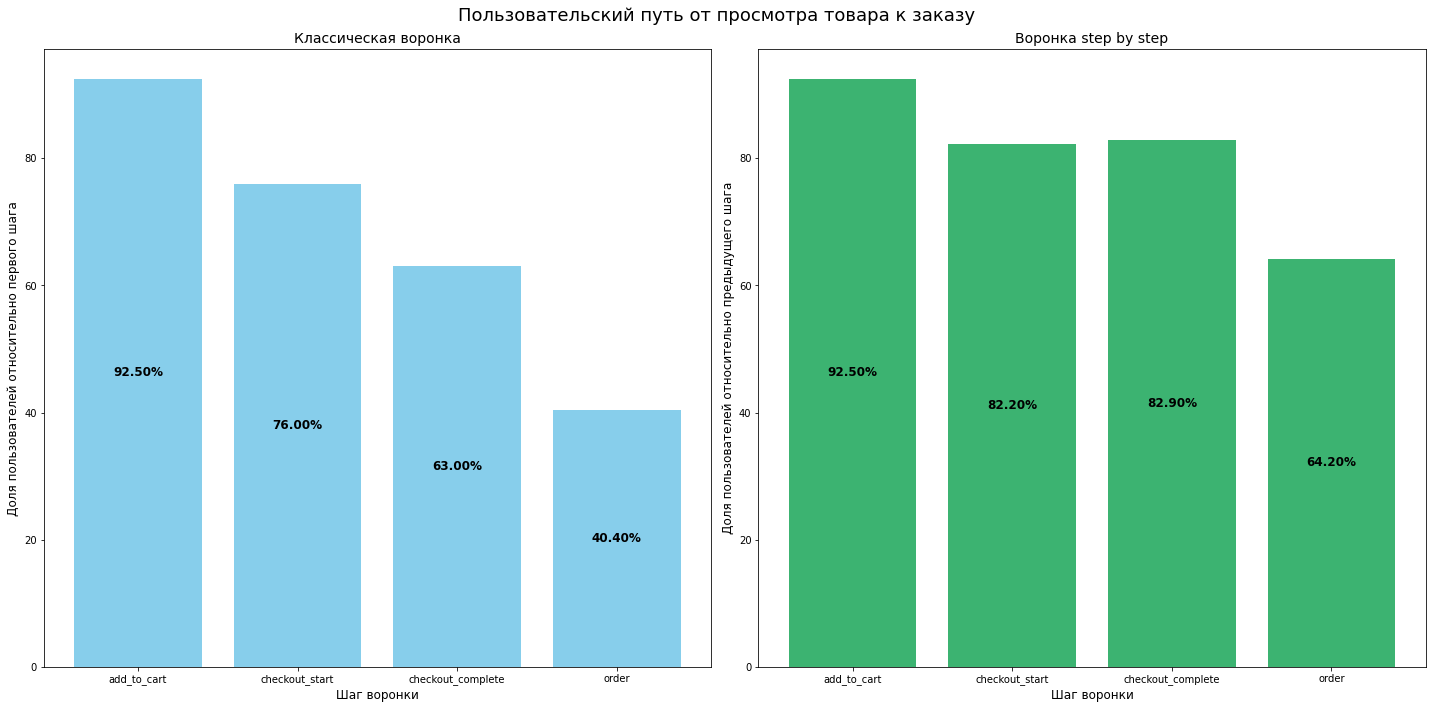

In [94]:
fig, axes = plt.subplots(1,2, figsize=(20, 10))

axes[0].bar(funnel_df['step'][1:], funnel_df['classic_cr_%'][1:], color='skyblue')
axes[0].set_title(f'Классическая воронка', fontsize=14)
axes[0].set_xlabel('Шаг воронки', fontsize=12)
axes[0].set_ylabel('Доля пользователей относительно первого шага', fontsize=12)

for patch in axes[0].patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[0].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )

axes[1].bar(funnel_df['step'], funnel_df['cr_previous_step_%'], color='mediumseagreen')
axes[1].set_title(f'Воронка step by step', fontsize=14)
axes[1].set_xlabel('Шаг воронки', fontsize=12)
axes[1].set_ylabel('Доля пользователей относительно предыдущего шага', fontsize=12)


for patch in axes[1].patches:
    height = patch.get_height()
    if pd.isna(height):
        continue
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    axes[1].text(
        x,
        y,
        f'{height:.2f}%',
        ha='center',
        va='center',
        color='black',
        fontsize=12,
        fontweight='bold'
    )


plt.suptitle(f'Пользовательский путь от просмотра товара к заказу', fontsize=18)
plt.tight_layout()
plt.show()

Пользовательский путь в целом выглядит адекватно, более 90% пользователей после просмотра товара добавляют его в корзину, а более 80% продолжают оформление покупки на следующих этапах. Наибольшие потери пользователей наблюдаются после завершения процесса оформления заказа. Между этапами checkout_complete и фактическим созданием заказа (логи в таблице orders) теряется около 36% пользователей. Стоит проверить, связано ли это с пользовательским поведением (возможно некоторые пользователи отваливаются на этапе выбора способа оплаты после подтверждения заказа) или с технической частью оплаты заказа.

Отдельно проверю воронки по каналам, так как ранее были найдены проблемы с эффективностью каналов привлечения

In [95]:
result = []

for channel in df_users['acq_channel'].unique():

    users_channel = df_users.loc[df_users['acq_channel'] == channel,'user_id']

    for step in funnel_steps:

        users_count = df_events[(df_events['event_type'] == step)&(df_events['user_id'].isin(users_channel))]['user_id'].nunique()

        result.append([channel, step, users_count])

    orders_count = df_orders[df_orders['user_id'].isin(users_channel)]['user_id'].nunique()

    result.append([channel, 'order', orders_count])

funnel_channels = pd.DataFrame(result, columns=['acq_channel', 'step', 'users'])

funnel_channels['classic_cr_%'] = funnel_channels.groupby('acq_channel')['users'].transform(lambda x: x / x.iloc[0] * 100)
funnel_channels['cr_previous_step_%'] = funnel_channels.groupby('acq_channel')['users'].transform(lambda x: x / x.shift(1) * 100)

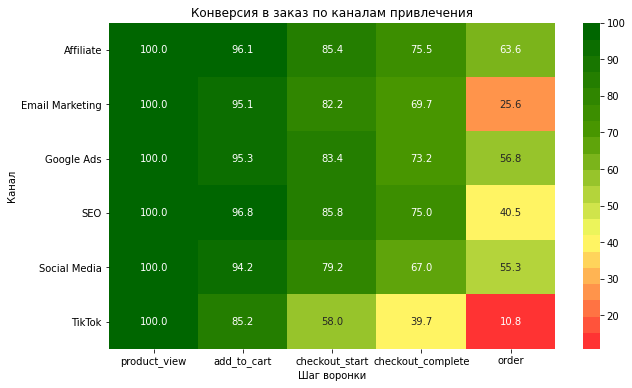

In [96]:
pivot = funnel_channels.pivot(
    index='acq_channel',
    columns='step',
    values='classic_cr_%'
)
pivot = pivot[['product_view', 'add_to_cart', 'checkout_start', 'checkout_complete', 'order']]

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap=cmap
)

plt.title('Конверсия в заказ по каналам привлечения')
plt.xlabel('Шаг воронки')
plt.ylabel('Канал')
plt.show()

Наиболее эффективным каналом с точки зрения конверсии в заказ является Affiliate, демонстрирующий максимальную конверсию пользователей из просмотра товара в заказ. Каналы Google Ads и Social Media также показывают высокие значения конверсии на всех этапах воронки. У TikTok конверсия из просмотра товара в заказ составляет всего 10,8%, что в несколько раз ниже остальных каналов. Пользователи данного канала массово теряются на этапах оформления покупки начиная с checkout_start. Также теряются пользователи после оформления заказа у Email Marketing более чем на 40%.

## Выводы на основе сегментации

<b><a href="https://docs.google.com/presentation/d/1wBbSNdd3Le-MRBNWSmU2MHzvvr1YLbrbphLXlp32Knk/edit?usp=sharing" target="_blank">Ссылка на презентацию с основными тезисами исследовательского анализа</a></b>

**Подробная аналитическая записка с выводами:**

**1. Каналы привлечения**

Анализ каналов привлечения показывает существенные различия как в объеме, так и в качестве привлекаемой аудитории. В первой половине года основным драйвером роста выступал Google Ads, однако с июля объем привлечения через этот канал начал снижаться, а к ноябрю канал был полностью отключен. Освободившийся объем трафика фактически был замещен TikTok, который стал крупнейшим источником новых пользователей во втором полугодии и обеспечил рост общей аудитории продукта.

Однако увеличение числа привлеченных пользователей не привело к такому же росту бизнес-показателей. Несмотря на высокие значения DAU и MAU, аудитория TikTok демонстрирует самое низкое удержание среди всех каналов, хуже конвертируется в заказ и показывает минимальные значения ARPU и ARPPU. Это свидетельствует о том, что канал эффективно привлекает пользователей, но качество этого трафика существенно ниже по сравнению с другими источниками.

Наиболее качественную аудиторию привлекают Affiliate, SEO и Social Media. Пользователи из этих каналов демонстрируют высокую конверсию в заказ и стабильно находятся среди лидеров по монетизационным метрикам. Google Ads, несмотря на снижение объемов привлечения во втором полугодии, также показывает хорошие показатели конверсии и удержания, что говорит о более высокой ценности пользователей, привлеченных через этот канал.

Таким образом, во второй половине года продукту удалось нарастить аудиторию за счет TikTok, однако рост пользовательской базы сопровождался снижением среднего качества привлекаемого трафика. Это может частично объяснять наблюдаемое ухудшение конверсии в заказ, снижение ARPU и ослабление монетизации продукта в конце года. При дальнейшем развитии маркетинговых инвестиций важно уделить особое внимание масштабированию каналов Affiliate, SEO и Social Media, а также провести дополнительный анализ причин низкой эффективности TikTok и возможностей повышения качества привлекаемой через него аудитории.

**2. Сегменты покупателей**

Анализ покупательских сегментов показал, что различия между сегментами обусловлены преимущественно частотой покупок, а не размером среднего чека. Значение AOV остается практически одинаковым для всех групп пользователей, тогда как количество заказов на пользователя существенно различается. Наиболее ценным сегментом являются пользователи regular: они совершают в среднем 5,7 заказа на пользователя и формируют максимальную выручку на платящего клиента (ARPPU около 80 тыс). Это указывает на то, что потенциал роста выручки продукта связан прежде всего с увеличением доли повторных покупок и переводом пользователей из сегментов one_time и rare в более лояльные сегменты.

Если стимулировать повторные покупки пользователей сегментов one_time и rare (персональные предложения, бонусы за повторный заказ, программы лояльности), то выручка будет расти быстрее, чем при попытках увеличить средний чек, поскольку основной фактор различий между сегментами это частота покупок.

**3. География покупателей**

Анализ регионов не выявил существенных различий в покупательском поведении пользователей. Лидерами по выручке и количеству заказов являются Москва и группа «Другие регионы», однако их преимущество объясняется прежде всего большим объемом аудитории. Средний чек в разных регионах находится на сопоставимом уровне, а отношение количества заказов к числу пользователей отличается незначительно. Это говорит о том, что продукт одинаково востребован в разных регионах, а основным драйвером роста выручки остается масштабирование пользовательской базы, а не региональные особенности поведения клиентов.

**4. Устройства пользователей**

Анализ устройств не выявил существенных различий в покупательском поведении пользователей. Конверсия в заказ, средний чек и выручка на платящего пользователя находятся на сопоставимом уровне для desktop, mobile и tablet. Пользователи планшетов демонстрируют немного более высокую частоту заказов и ARPPU, однако различия остаются незначительными. Таким образом, тип устройства не является ключевым фактором, влияющим на монетизацию продукта или эффективность воронки.

**5. Категории товаров**

Анализ категорий товаров показал существенные различия в их вкладе в выручку и ценность покупателей. Наиболее массовой категорией являются продукты питания, которые привлекают почти в три раза больше покупателей, чем любая другая категория. Однако данная категория характеризуется самым низким средним чеком и одной из самых низких выручек на покупателя, что говорит о высокой популярности, но низкой монетизации.

Основную выручку продукту приносят категории мебели для дома, бытовой техники и украшений с часами. Несмотря на сравнительно небольшое количество покупателей, эти категории демонстрируют самые высокие значения среднего чека и ARPPU, обеспечивая значительный вклад в прибыль маркетлейса.

Частота покупок между категориями отличается незначительно, ключевые различия между категориями обусловлены не количеством совершаемых заказов, а стоимостью приобретаемых товаров.

Таким образом, категории можно условно разделить на два типа: массовые категории, обеспечивающие широкий охват аудитории (продукты питания, детские товары, зоотовары), и высокомаржинальные категории, формирующие основную выручку бизнеса (мебель, бытовая техника, украшения и часы). Для роста выручки перспективным направлением может стать продвижение высокомаржинальных категорий, а также стимулирование покупателей массовых категорий к переходу в более дорогие товарные сегменты через персональные рекомендации, подборки товаров и кросс-продажи.

**6. Пользовательский путь**

Верхняя часть воронки работает эффективно, более 90% пользователей после просмотра товара добавляют его в корзину, а более 80% продолжают оформление покупки на следующих этапах.

Наибольшие потери пользователей наблюдаются после завершения процесса оформления заказа. Между этапами checkout_complete и фактическим созданием заказа теряется около 36% пользователей. Поскольку основной отток пользователей происходит после завершения оформления заказа, перспективным направлением для улучшения конверсии может стать анализ процесса подтверждения и оплаты заказа. Если упростить данный этап или устранить возможные технические проблемы, общая конверсия воронки может существенно вырасти без дополнительных затрат.

Анализ воронки по каналам привлечения показал существенные различия в качестве привлекаемой аудитории. Наиболее эффективным каналом оказался Affiliate, демонстрирующий максимальную конверсию пользователей из просмотра товара в заказ. Каналы Google Ads и Social Media также показывают высокие значения конверсии на всех этапах воронки.

Наименее качественный трафик привлекается через TikTok. Несмотря на значительный объем новых пользователей и высокий уровень активности, конверсия из просмотра товара в заказ составляет всего 10,8%, что в несколько раз ниже остальных каналов. Пользователи данного канала массово теряются на этапах оформления покупки, что объясняет низкие значения ROI, ARPU и ARPPU для этого источника привлечения.

Также для канала Email Marketing наблюдается значительный отток пользователей между этапами checkout_complete и фактическим созданием заказа. Если проанализировать причины отказа и доработать процесс завершения покупки (например упрощения оплаты или устранения возможных технических проблем) конверсия в заказ может вырасти.

**Инсайты**

- Основные точки роста продукта следует искать не в географии или платформе использования, а в качестве привлекаемого трафика и работе с покупательскими сегментами. 
- Одним из ключевых факторов снижения эффективности продукта во втором полугодии может являться снижение качества привлекаемой аудитории чеез неэффективные каналы привлечения.
- Самый эффективный канал привлечения пользователей Affiliate (окупается в первый месяц, высокая конверсия в заказ).
- Самый неэффективный канал TikTok обеспечивает большой приток новых пользователей, но показывает худшую монетизацию (отрицательный ROI на протяжении всего года, минимальная конверсия в заказ при высокой активности пользователей).
- Выручка маркетплейса зависит не от среднего чека, а от частоты заказов - наиболее прибыльной является сегмент регулярно заказывающих пользователей.
- Массовые категории обеспечивают основной охват аудитории и объем заказов, тогда как основной вклад в выручку формируют категории мебели, бытовой техники, украшений и часов.

**Гипотезы**

- *Стимулирование повторных покупок увеличит выручку*

Поскольку сегмент regular формирует основную часть выручки и демонстрирует максимальную частоту покупок, можно выдвинуть гипотезу, что если стимулировать пользователей сегментов one_time и rare к повторным заказам через персональные рекомендации, бонусы или скидки на следующую покупку, то доля пользователей сегмента regular увеличится.

- *Продвижение категорий с высоким средним чеком увеличит выручку*

Если продвигать категории мебели для дома, бытовой техники, украшений и часов в рекомендациях и маркетинговых коммуникациях, то средняя выручка на пользователя возрастет, так как данные категории имеют самые высокие значения среднего чека и ARPPU среди всех товарных направлений. Стимулирование покупателей массовых категорий к переходу в более дорогие товарные сегменты через персональные рекомендации, подборки товаров и кросс-продажи может также позитивно сказаться на выручке.

- *Изменение рекламных кампаний в TikTok повысит окупаемость канала*

Если изменить содержание и таргетинг рекламных кампаний в TikTok и сфокусироваться на аудитории с более высокой вероятностью покупки, то конверсия в заказ и ROI канала вырастут. На данный момент TikTok обеспечивает высокий приток пользователей и активность аудитории, однако показывает худшие показатели удержания, монетизации и конверсии в покупку среди всех каналов.

- *Перераспределение маркетингового бюджета в сторону более эффективных каналов увеличит прибыльность маркетинга*

Если увеличить инвестиции в канал Affiliate, SEO и Social Media при текущем качестве трафика, то общая эффективность привлечения пользователей возрастет, так как данные каналы демонстрируют лучшие показатели ROI, самые высокие конверсии в заказ и лучшие показатели монетизации по сравнению с другими источниками трафика.

----

# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


In [98]:
ab_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   user_id       831231 non-null  int64         
 2   event_date    831231 non-null  datetime64[ns]
 3   event_type    831231 non-null  object        
 4   os            831231 non-null  object        
 5   device        831231 non-null  object        
 6   product_name  409054 non-null  object        
 7   event_week    831231 non-null  datetime64[ns]
 8   event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 57.1+ MB


In [99]:
ab_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB


In [100]:
ab_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  datetime64[ns]
 8   cohort_month       22196 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 1.5+ MB


In [101]:
ab_split.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


Размеры таблиц разные, значит в таблицах с пользователями,событиями и заказами находятся не только участники эксперимента

In [102]:
ab_users['acq_channel'].value_counts()

TikTok    22196
Name: acq_channel, dtype: int64

In [103]:
ab_users = ab_users.merge(ab_split[['user_id','group']], on='user_id', how='inner')
ab_users.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group
0,44965,2025-01-01 18:10:00,66,M,Новосибирск,TikTok,one_time,2024-12-30,2025-01-01,control
1,44967,2025-01-01 11:29:00,70,M,Московская область,TikTok,rare,2024-12-30,2025-01-01,control
2,44968,2025-01-01 13:05:00,68,F,Нижний Новгород,TikTok,regular,2024-12-30,2025-01-01,control
3,44969,2025-01-01 00:23:00,24,F,Краснодар,TikTok,medium,2024-12-30,2025-01-01,treatment
4,44970,2025-01-01 06:33:00,50,M,Санкт-Петербург,TikTok,regular,2024-12-30,2025-01-01,control


In [104]:
ab_users.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2968 entries, 0 to 2967
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            2968 non-null   int64         
 1   registration_date  2968 non-null   datetime64[ns]
 2   age                2968 non-null   int64         
 3   gender             2968 non-null   object        
 4   region             2968 non-null   object        
 5   acq_channel        2968 non-null   object        
 6   buyer_segment      2968 non-null   object        
 7   cohort_week        2968 non-null   datetime64[ns]
 8   cohort_month       2968 non-null   datetime64[ns]
 9   group              2968 non-null   object        
dtypes: datetime64[ns](3), int64(2), object(5)
memory usage: 255.1+ KB


In [105]:
ab_orders = ab_orders.merge(ab_split, on='user_id', how='inner')
ab_orders.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment


In [106]:
ab_orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 255 entries, 0 to 254
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       255 non-null    int64         
 1   user_id        255 non-null    int64         
 2   order_date     255 non-null    datetime64[ns]
 3   product_name   255 non-null    object        
 4   quantity       255 non-null    int64         
 5   unit_price     255 non-null    float64       
 6   total_price    255 non-null    float64       
 7   category_name  255 non-null    object        
 8   order_week     255 non-null    datetime64[ns]
 9   order_month    255 non-null    datetime64[ns]
 10  group          255 non-null    object        
dtypes: datetime64[ns](3), float64(2), int64(3), object(3)
memory usage: 23.9+ KB


#### Проверка сплитования

In [107]:
groups = ab_users.groupby('group')['user_id'].nunique().reset_index()
groups['ratio_%'] = round(groups['user_id'] / groups['user_id'].sum() * 100, 2)
groups

,group,user_id,ratio_%
0,control,1503,50.64
1,treatment,1465,49.36


In [108]:
users_groups = ab_users.groupby('user_id')['group'].nunique().reset_index()
flawed_users = users_groups[users_groups['group']>1]['user_id'].nunique()

print(f'Количество пользователей, попавших в обе группы: {flawed_users}')

Количество пользователей, попавших в обе группы: 0


Группы по количеству пользователей разбиты примерно поровну и не пересекаются

In [109]:
ab_users.groupby('group')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,1503.0,43.744511,15.294662,18.0,30.5,43.0,57.0,70.0
treatment,1465.0,44.324915,15.036416,18.0,31.0,44.0,58.0,70.0


In [110]:
pd.crosstab(ab_users['gender'], ab_users['group'], normalize='columns')

group,control,treatment
gender,,
F,0.495675,0.522867
M,0.504325,0.477133


In [111]:
regions_groups = ab_users.groupby(['region','group'])['user_id'].nunique().reset_index()

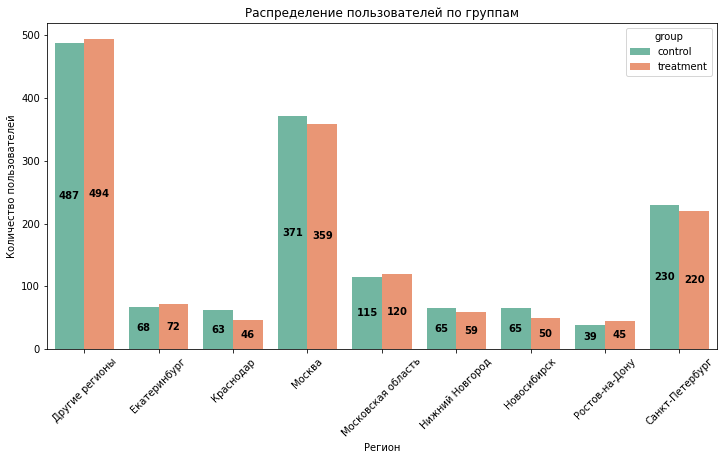

In [112]:
plt.figure(figsize=(12,6))

ax = sns.barplot(data=regions_groups, x='region', y='user_id', hue='group', palette='Set2')

for patch in ax.patches:
    height = patch.get_height()
    y = height / 2
    x = patch.get_x() + patch.get_width() / 2
    ax.text(
        x,
        y,
        f'{height:.0f}',
        ha='center',
        va='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Распределение пользователей по группам')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.xticks(rotation = 45)
plt.show()

In [113]:
pd.crosstab(ab_users['buyer_segment'], ab_users['group'], normalize='columns')

group,control,treatment
buyer_segment,,
medium,0.358616,0.361775
one_time,0.143047,0.167918
rare,0.303393,0.294198
regular,0.194943,0.176109


Сплитование проведено корректно, распределение пользователей по группам в целом и по признакам примерно одинаково.

#### Ключевая метрика - CR в первую покупку

In [114]:
def calc_diff(df, metric_col):
    control = df[df['group'] == 'control'][metric_col].iloc[0]
    treatment = df[df['group'] == 'treatment'][metric_col].iloc[0]

    abs_diff = treatment - control
    rel_diff = (treatment - control) / control * 100

    return pd.DataFrame({
        'control': [round(control, 6)],
        'treatment': [round(treatment, 6)],
        'abs_diff': [round(abs_diff, 6)],
        'rel_diff': f'{round(rel_diff, 2)}%'
    })

In [115]:
first_order = ab_orders.groupby('user_id')['order_date'].min().reset_index()
first_order = first_order.rename(columns={'order_date':'first_order_date'})

start = ab_users['registration_date'].min()
end = ab_users['registration_date'].max()

cr_df = ab_users.merge(first_order, on='user_id', how='left')

cr_df['first_order'] = (
    cr_df['first_order_date'].notna() &
    (cr_df['first_order_date'] >= cr_df['registration_date']) &
    (cr_df['first_order_date'] >= start) &
    (cr_df['first_order_date'] <= end)
)

cr = cr_df.groupby('group')['first_order'].mean().reset_index().rename(columns={'first_order':'cr'})

In [116]:
print('Значения ключевой метрики в контрольной и тестовой группах:')
calc_diff(cr, 'cr')

Значения ключевой метрики в контрольной и тестовой группах:


,control,treatment,abs_diff,rel_diff
0,0.010645,0.075085,0.06444,605.33%


Виден значительный эффект конверсии, проверю:

In [117]:
check = cr_df.groupby('group')['first_order'].sum().reset_index()
check = check.merge(groups[['group', 'user_id']], on='group')
check

,group,first_order,user_id
0,control,16,1503
1,treatment,110,1465


При почти равных группах, в тестовой группе количество пользователей, сделавших первый заказ, выросло почти в 7 раз

Так как сравниваю доли, использую ztest:

In [118]:
ztest_df = cr_df.groupby('group')['first_order'].agg(['sum','count'])

stat, pvalue = proportions_ztest(
    count=ztest_df['sum'],
    nobs=ztest_df['count']
)

if pvalue > 0.05:
    print(f'P-value различий ключевой метрики в группах {pvalue}. Различия не являются статистически значимыми')
else:
    print(f'P-value различий ключевой метрики в группах {pvalue}. Различия статистически значимы')

P-value различий ключевой метрики в группах 3.164905789805764e-18. Различия статистически значимы


#### Барьерная метрика - общая выручка от пользователей

In [119]:
orders = ab_orders[(ab_orders['order_date'] >= start) &(ab_orders['order_date'] <= end)]

revenue = orders.groupby('group')['total_price'].sum().reset_index()
revenue['total_revenue'] = revenue['total_price'] * 0.05

In [120]:
print('Значения барьерной метрики в контрольной и тестовой группах:')
calc_diff(revenue, 'total_revenue')

Значения барьерной метрики в контрольной и тестовой группах:


,control,treatment,abs_diff,rel_diff
0,18918.645,192279.8515,173361.2065,916.35%


Общая выручка от пользователей TikTok не снизилась, а значительно выросла. На это могли повлиять как значительно возросшее количество покупателей, так и вспомогательные метрики, считаю ниже:

#### Вспомогательные метрики

**ARPU**

In [121]:
users_orders = ab_orders.groupby('user_id').agg(
    total_price=('total_price', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

In [122]:
metrics_df = ab_users.merge(users_orders, on='user_id', how='left')

metrics_df['total_orders'] = metrics_df['total_orders'].fillna(0)
metrics_df['total_price'] = metrics_df['total_price'].fillna(0)
metrics_df['revenue'] = metrics_df['total_price'] * 0.05

metrics_df.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group,total_price,total_orders,revenue
0,44965,2025-01-01 18:10:00,66,M,Новосибирск,TikTok,one_time,2024-12-30,2025-01-01,control,0.00,0.0,0.0000
1,44967,2025-01-01 11:29:00,70,M,Московская область,TikTok,rare,2024-12-30,2025-01-01,control,0.00,0.0,0.0000
2,44968,2025-01-01 13:05:00,68,F,Нижний Новгород,TikTok,regular,2024-12-30,2025-01-01,control,0.00,0.0,0.0000
3,44969,2025-01-01 00:23:00,24,F,Краснодар,TikTok,medium,2024-12-30,2025-01-01,treatment,0.00,0.0,0.0000
4,44970,2025-01-01 06:33:00,50,M,Санкт-Петербург,TikTok,regular,2024-12-30,2025-01-01,control,14715.69,1.0,735.7845


In [123]:
arpu = metrics_df.groupby('group')['revenue'].mean().reset_index().rename(columns={'revenue':'arpu'})

In [124]:
print('Значения ARPU в контрольной и тестовой группах:')
calc_diff(arpu, 'arpu')

Значения ARPU в контрольной и тестовой группах:


,control,treatment,abs_diff,rel_diff
0,12.587255,131.249045,118.66179,942.71%


In [125]:
control_arpu = metrics_df[metrics_df['group'] == 'control']['revenue']
treatment_arpu = metrics_df[metrics_df['group'] == 'treatment']['revenue']
stat, pvalue = ttest_ind(control_arpu, treatment_arpu, equal_var=False)

if pvalue > 0.05:
    print(f'P-value различий вспомогательной метрики ARPU в группах {pvalue}. Различия не являются статистически значимыми')
else:
    print(f'P-value различий вспомогательной метрики ARPU в группах {pvalue}. Различия статистически значимы')

P-value различий вспомогательной метрики ARPU в группах 4.093823695234315e-09. Различия статистически значимы


**ARPPU**

In [126]:
buyers = metrics_df[metrics_df['revenue']>0].copy()
arppu = buyers.groupby('group')['revenue'].mean().reset_index().rename(columns={'revenue':'arppu'})

In [127]:
print('Значения ARPPU в контрольной и тестовой группах:')
calc_diff(arppu, 'arppu')

Значения ARPPU в контрольной и тестовой группах:


,control,treatment,abs_diff,rel_diff
0,1182.415312,1747.99865,565.583337,47.83%


In [128]:
control_arppu = buyers[buyers['group'] == 'control']['revenue']
treatment_arppu = buyers[buyers['group'] == 'treatment']['revenue']
stat, pvalue = ttest_ind(control_arppu, treatment_arppu, equal_var=False)

if pvalue > 0.05:
    print(f'P-value различий вспомогательной метрики ARPPU в группах {pvalue}. Различия не являются статистически значимыми')
else:
    print(f'P-value различий вспомогательной метрики ARPPU в группах {pvalue}. Различия статистически значимы')

P-value различий вспомогательной метрики ARPPU в группах 0.04927676444397778. Различия статистически значимы


**AOV**

In [129]:
ab_orders.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment


In [130]:
aov = ab_orders.groupby('group')['total_price'].mean().reset_index().rename(columns={'total_price':'aov'})

In [131]:
print('Значения AOV в контрольной и тестовой группах:')
calc_diff(aov, 'aov')

Значения AOV в контрольной и тестовой группах:


,control,treatment,abs_diff,rel_diff
0,15765.5375,16647.60619,882.06869,5.59%


In [132]:
control_aov = ab_orders[ab_orders['group'] == 'control']['total_price']
treatment_aov = ab_orders[ab_orders['group'] == 'treatment']['total_price']
stat, pvalue = ttest_ind(control_aov, treatment_aov, equal_var=False)

if pvalue > 0.05:
    print(f'P-value различий вспомогательной метрики AOV в группах {pvalue}. Различия не являются статистически значимыми')
else:
    print(f'P-value различий вспомогательной метрики AOV в группах {pvalue}. Различия статистически значимы')

P-value различий вспомогательной метрики AOV в группах 0.7872035213045679. Различия не являются статистически значимыми


## Выводы из анализа эксперимента

#### Анализ результатов теста

**Суть эксперимента** - пользователям TikTok из тестовой группы предоставлялся бонус на первую покупку. Контрольная группа не получала бонус на первую покупку.

**Цель эксперимента** - проверить, приведет ли представление бонуса к росту конверсии в первую покупку без ухудшения монетизации продукта.

Эксперимент проводился в формате rolling split среди новых пользователей привлеченных через канал TikTok. Пользователи равномерно распределялись между контрольной и тестовой группами по дате регистрации. 

**Нулевая гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, *приведет* к увеличению конверсии в первую покупку.

**Альтернативная гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, *не приведет* к увеличению конверсии в первую покупку.

**Сплитование:**

- контрольная группа — 1503 пользователя;
- тестовая группа — 1465 пользователей.

    Распределение пользователей между группами является сбалансированным как в целом, так и в разрезе пользовательских признаков (пол, регион, возраст, покупательский сегмент).

**Ключевая метрика - CR в первый заказ**

Доля пользователей, совершивших первый заказ после регистрации, составила 1.06% в контрольной группе и 7.51% в тестовой группе. Абсолютный прирост конверсии составил 6.44%, относительный прирост — 605%. Значительный рост конверсии обусловлен возросшим количеством пользователей, совершивших первую покупку после регистрации, в тестовой группе (110 пользователей против 16 в контрольной группе). Эффект является стстистически значимым (p-value < 0.001). 

*Таким образом, предоставление бонуса на первую покупку привело к существенному росту доли совершения первой покупки среди пользователей пришедших из TikTok.*

**Барьерная метрика - общая выручка пользователей TikTok**

Внедрение бонуса не должно было ухудшить монетизацию продукта. В ходе эксперимента общая выручка тестовой группы оказалась выше контрольной на 916%.

Негативного влияния эксперимента на выручку не обнаружено. Напротив, рост конверсии сопровождался существенным увеличением объема выручки тестовой группы.

**Прокси метрики**

- **ARPU** тестовой группы составила 131.25 р, контрольной группы 12.59р. Относительный рост составил 943%. Рост ARPU объясняется существенным увеличением числа пользователей совершивших первую покупку после регистрации. Эффект является статистически значимым (p-value < 0.001).

- **ARPPU** тестовой группы составила 1748 р, контрольной группы 1182 р. Относительный рост составил 47.8%. Результат свидетельствует о том, что пользователи тестовой группы не только чаще совершали первую покупку, но и приносили сопоставимую либо более высокую выручку. Эффект является статистически значимым (p-value 0.049).

- **AOV** Изменение среднего чека оказалось наименее выраженным среди остальных метрик. AOV тестовой группы составил 16647 р, контрольной группы 15765 р, относительная разница 5.6%. Эффект не является статистически значимым (p-value 0.787). Бонус на первую покупку не повысил средий чек, но и не понизил его.

**Итог эксперимента**

Эксперимент показал положительный результат.

Предоставление бонуса на первую покупку пользователям пришедшим из TikTok привело к статистически значимому росту конверсии в первую покупку с 1.06% до 7.51% (+6.44%, p-value < 0.001).

Рост конверсии сопровождается увеличением общей выручки и ARPU. Также наблюдается рост ARPPU, при этом средний чек значимо не изменился.

Барьерная метрика не ухудшилась, что свидетельствует об отсутствии негативного влияния бонуса на монетизацию продукта.

Таким образом, *нулевая гипотеза эксперимента подтверждается:* предоставление бонуса на первую покупку пользователям TikTok приводит к повышению конверсии в первую покупку.

Рекомендуется продолжить предоставлять бонус на первую покупку для пользователей из канала TikTok, продолжить мониторинг ключевых метрик после запуска фичи для подтверждения устойчивости полученного эффекта в более длительном периоде наблюдений.